[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/information_theory/02_joint_and_conditional_entropy/first_principles.ipynb)

# Module 02 — Joint and Conditional Entropy

## 1. Why This Module Exists

Entropy measures the uncertainty of one random variable. Almost nothing interesting is one
random variable.

A language model sees a token *and* its context. A sensor reads a signal *and* its noise. A
classifier sees features *and* a label. The question is never "how uncertain is $Y$?" but
"how much uncertainty about $Y$ is left once $X$ has been seen?"

This module builds the accounting system that answers it. **Joint entropy** $H(X, Y)$ is the
total uncertainty of the pair; **conditional entropy** $H(Y \mid X)$ is the part that survives
observing $X$; and the **chain rule** $H(X, Y) = H(X) + H(Y \mid X)$ says the ledger balances
exactly, with no remainder.

Everything downstream is a consequence. Supervised learning drives $H(Y \mid X)$ down.
Autoregressive language modelling *is* the chain rule, applied one token at a time. Fano's
inequality turns whatever conditional entropy is left into a hard floor under the error rate of
every classifier that will ever be trained on those features.

## 2. Intuition

Draw the uncertainty of $X$ as a region of area $H(X)$ and the uncertainty of $Y$ as a region of
area $H(Y)$. Dependence makes the two regions overlap.

The union is the joint entropy $H(X, Y)$: everything you would have to describe to pin down both
variables. The part of $Y$'s region outside $X$'s is $H(Y \mid X)$: what is left to describe
*after* $X$ has been handed to you for free.

Read that picture as an equation and you have the chain rule. Total area equals $X$'s area plus
the crescent of $Y$ that $X$ does not cover.

The overlap can never be negative, and that single fact is the whole content of *conditioning
reduces entropy*: side information cannot cost you. What it can do — and this is the subtlety
that trips everyone — is cost you on a *particular* day. A specific observation $X = x$ may leave
you more uncertain than you started. Only the average over observations is guaranteed to help.

Everything in Sections 3 to 5 is that picture written out in sums, plus the one place where the
picture breaks: with three or more variables the "triple overlap" can be negative, so the areas
stop being areas.

The first code cell is the notebook preamble. It fixes plotting defaults, seeds the single random
generator used everywhere below, defines the entropy helpers that every later cell reuses, and
prints the machine epsilon that all residual claims are measured against.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.0, 4.0),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

EPS = np.finfo(float).eps


def H(p):
    """Shannon entropy in bits, with the 0 log 0 = 0 convention."""
    p = np.asarray(p, dtype=float).ravel()
    p = p[p > 0.0]
    return float(-(p * np.log2(p)).sum()) + 0.0   # the +0.0 turns -0.0 into 0.0


def Hb(t):
    """Binary entropy function in bits."""
    return H([t, 1.0 - t])


def entropies(P):
    """Joint table -> (H(X,Y), H(X), H(Y), H(Y|X), H(X|Y)) in bits."""
    P = np.asarray(P, dtype=float)
    Hxy, Hx, Hy = H(P), H(P.sum(axis=1)), H(P.sum(axis=0))
    return Hxy, Hx, Hy, Hxy - Hx, Hxy - Hy


print(f"machine epsilon = {EPS:.4e}")
print(f"H of a fair coin = {Hb(0.5):.4f} bits")

machine epsilon = 2.2204e-16
H of a fair coin = 1.0000 bits


Every residual reported later is quoted as a multiple of this number. All logarithms in this
module are base $2$ and every numeric answer is in **bits**, following
[the notation register](../../docs/notation.md).

The figure below draws the picture described above for the running example of this module, the
joint table

$$
p(0,0) = \tfrac12, \quad p(0,1) = \tfrac14, \quad p(1,0) = 0, \quad p(1,1) = \tfrac14 .
$$

The left panel is the information diagram with its regions labelled by their measured areas; the
right panel is the same five numbers as an additive ledger, decomposed both ways round.

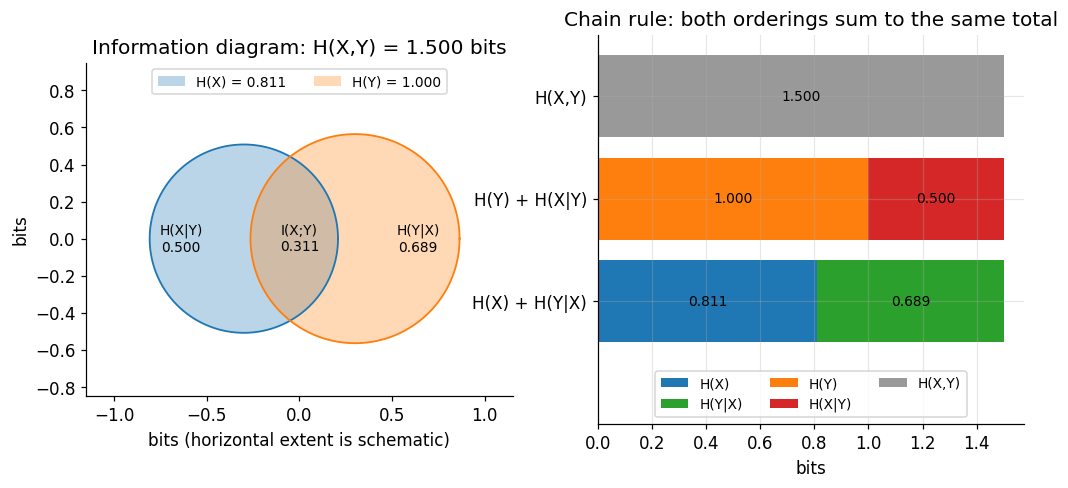

H(X,Y) = 1.500000   H(X) = 0.811278   H(Y) = 1.000000
H(Y|X) = 0.688722   H(X|Y) = 0.500000   overlap = 0.311278
chain-rule residual |H(X,Y) - H(X) - H(Y|X)| = 0.000e+00


In [2]:
P_run = np.array([[0.5, 0.25],
                  [0.0, 0.25]])
Hxy, Hx, Hy, Hy_x, Hx_y = entropies(P_run)
I_xy = Hx + Hy - Hxy

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.0, 4.6))

# --- left: information diagram, circle areas proportional to H(X) and H(Y) ---
rx, ry = np.sqrt(Hx / np.pi), np.sqrt(Hy / np.pi)
cx, cy = -0.30, 0.30
theta = np.linspace(0.0, 2.0 * np.pi, 400)
ax0.fill(cx + rx * np.cos(theta), rx * np.sin(theta), alpha=0.30, label=f"H(X) = {Hx:.3f}")
ax0.fill(cy + ry * np.cos(theta), ry * np.sin(theta), alpha=0.30, label=f"H(Y) = {Hy:.3f}")
ax0.plot(cx + rx * np.cos(theta), rx * np.sin(theta), lw=1.2)
ax0.plot(cy + ry * np.cos(theta), ry * np.sin(theta), lw=1.2)
ax0.annotate(f"H(X|Y)\n{Hx_y:.3f}", (cx - 0.34, 0.0), ha="center", va="center", fontsize=9)
ax0.annotate(f"I(X;Y)\n{I_xy:.3f}", (0.0, 0.0), ha="center", va="center", fontsize=9)
ax0.annotate(f"H(Y|X)\n{Hy_x:.3f}", (cy + 0.34, 0.0), ha="center", va="center", fontsize=9)
ax0.set_xlim(-1.15, 1.15)
ax0.set_ylim(-0.85, 0.95)
ax0.set_aspect("equal")
ax0.grid(False)
ax0.set_xlabel("bits (horizontal extent is schematic)")
ax0.set_ylabel("bits")
ax0.set_title(f"Information diagram: H(X,Y) = {Hxy:.3f} bits")
ax0.legend(loc="upper center", fontsize=9, ncol=2)

# --- right: the chain rule as a stacked ledger ---
ax1.barh(0, Hx, color="C0", label="H(X)")
ax1.barh(0, Hy_x, left=Hx, color="C2", label="H(Y|X)")
ax1.barh(1, Hy, color="C1", label="H(Y)")
ax1.barh(1, Hx_y, left=Hy, color="C3", label="H(X|Y)")
ax1.barh(2, Hxy, color="0.6", label="H(X,Y)")
ax1.set_yticks([0, 1, 2])
ax1.set_yticklabels(["H(X) + H(Y|X)", "H(Y) + H(X|Y)", "H(X,Y)"])
for y, parts in [(0, [(0.0, Hx), (Hx, Hy_x)]),
                 (1, [(0.0, Hy), (Hy, Hx_y)]),
                 (2, [(0.0, Hxy)])]:
    for left, w in parts:
        ax1.annotate(f"{w:.3f}", (left + w / 2, y), ha="center", va="center", fontsize=9)
ax1.set_ylim(-1.2, 2.6)
ax1.set_xlabel("bits")
ax1.set_title("Chain rule: both orderings sum to the same total")
ax1.legend(fontsize=9, ncol=3, loc="lower center")
plt.show()

print(f"H(X,Y) = {Hxy:.6f}   H(X) = {Hx:.6f}   H(Y) = {Hy:.6f}")
print(f"H(Y|X) = {Hy_x:.6f}   H(X|Y) = {Hx_y:.6f}   overlap = {I_xy:.6f}")
print(f"chain-rule residual |H(X,Y) - H(X) - H(Y|X)| = {abs(Hxy - Hx - Hy_x):.3e}")

The two bars on the right have identical length: revealing $X$ first and revealing $Y$ first cost
the same $1.5$ bits in total, split differently. That equality is the chain rule, and its residual
is exactly zero to machine precision.

The overlap of $0.311$ bits is the amount by which the two circles are *not* disjoint. It is what
knowing either variable saves you on the other, and it is what Section 4 will show can never be
negative.

## 3. Definitions

Throughout, $X$ and $Y$ are random variables on **finite** alphabets $\mathcal{X}$ and
$\mathcal{Y}$ with joint probability mass function $p(x, y)$, marginals
$p(x) = \sum_y p(x,y)$ and $p(y) = \sum_x p(x,y)$, and conditionals
$p(y \mid x) = p(x,y)/p(x)$ defined whenever $p(x) \gt 0$.

Logarithms are base $2$ and entropies are in **bits**. The convention $0 \log 0 = 0$ is used
everywhere; it is the continuous extension, since $t \log t \to 0$ as $t \downarrow 0$.

Finiteness of the alphabets is assumed so that every entropy below is a finite sum of finite
terms. The symbol conventions are those of [the notation register](../../docs/notation.md):
$H(X, Y)$ always means **joint** entropy of a pair of random variables, never cross-entropy.

### Definition 3.1 — Joint entropy

The **joint entropy** of $(X, Y)$ is

$$
H(X, Y) = -\sum_{x \in \mathcal{X}} \sum_{y \in \mathcal{Y}} p(x, y) \log p(x, y) .
$$

This is not a new quantity: it is the entropy of the single random variable $Z = (X, Y)$ living
on the product alphabet $\mathcal{X} \times \mathcal{Y}$. The definition extends verbatim to any
finite collection, $H(X_1, \dots, X_n)$.

### Definition 3.2 — Conditional entropy given an event

For $x$ with $p(x) \gt 0$, the **slice entropy** is the ordinary entropy of the conditional
distribution $p(\cdot \mid x)$:

$$
H(Y \mid X{=}x) = -\sum_{y} p(y \mid x) \log p(y \mid x) .
$$

One number per row of the joint table. It is what your uncertainty about $Y$ would become if you
were told that $X = x$ and nothing else.

### Definition 3.3 — Conditional entropy

The **conditional entropy** of $Y$ given $X$ is the $p(x)$-weighted average of the slices:

$$
H(Y \mid X) = \sum_{x} p(x) \, H(Y \mid X{=}x) = -\sum_{x, y} p(x, y) \log p(y \mid x) .
$$

Equivalently $H(Y \mid X) = \mathbb{E}\bigl[-\log p(Y \mid X)\bigr]$: the average surprise of $Y$
to a forecaster who is told $X$ and knows the true conditional law.

The averaging is not cosmetic. Definition 3.2 is a random quantity indexed by the observation;
Definition 3.3 is the single number you can commit to *before* observing. Theorem 4.4 is a
statement about the second, and Example 6.3 shows it is false for the first.

### Definition 3.4 — Relative entropy

For probability mass functions $p$ and $q$ on a finite set $\mathcal{A}$ with
$q(a) = 0 \Rightarrow p(a) = 0$ (written $p \ll q$),

$$
D(p \parallel q) = \sum_{a \in \mathcal{A}} p(a) \log \frac{p(a)}{q(a)} .
$$

It is introduced here only as the tool that proves Theorem 4.4; its own theory —
$f$-divergences, Pinsker, the forward-versus-reverse asymmetry — is the subject of
[Module 04](../04_kl_divergence_and_f_divergences/). Lemma 4.3 proves from scratch the one
property this module needs.

### Definition 3.5 — The overlap, and independence

The **overlap** of the two entropies is

$$
I(X; Y) = H(X) + H(Y) - H(X, Y) ,
$$

the shaded lens in the Section 2 figure. Theorem 4.4 shows $I(X; Y) \ge 0$ and that it vanishes
exactly at independence, $p(x,y) = p(x)p(y)$ for all $(x,y)$.

The quantity is **mutual information**; it is developed properly in
[Module 05](../05_mutual_information/). Nothing in this module depends on that development —
$I(X;Y)$ is used below purely as a name for the subadditivity gap.

### Definition 3.6 — Binary entropy function

For $t \in [0, 1]$,

$$
H_b(t) = -t \log t - (1-t)\log(1-t) ,
$$

the entropy of a $\mathrm{Bernoulli}(t)$ variable, with $H_b(0) = H_b(1) = 0$ and
$H_b(\tfrac12) = 1$ bit. It appears in Fano's inequality (Theorem 4.8) and in every binary channel
computation below.

### Definition 3.7 — Stationary process and entropy rate

A process $(X_t)_{t \ge 1}$ on a finite alphabet is **stationary** when the joint law of
$(X_{t_1 + s}, \dots, X_{t_k + s})$ does not depend on the shift $s \ge 0$.

Its **entropy rate**, when the limit exists, is

$$
H_\infty = \lim_{n \to \infty} \frac{1}{n} H(X_1, \dots, X_n) ,
$$

the average number of bits per symbol needed to describe a long stretch of the process.
Theorem 4.10 shows the limit exists for every stationary process and identifies it.

## 4. Main Results

Theorem 4.1 is the identity the module is named after and everything else leans on it.
Theorem 4.2 is its $n$-variable form.

Lemma 4.3 is the only external ingredient the module needs, and it is proved here from a
one-line calculus bound rather than imported. Theorems 4.4 to 4.7 are the four structural facts
that follow: conditioning helps, dependence compresses, the quantities are boxed between
computable limits, and zero residual uncertainty means determinism.

Theorem 4.8 (Fano), Theorem 4.9 (Han) and Theorem 4.10 (entropy rate) are the three consequences
that reach outside the module: a floor under classification error, a counting inequality, and the
bits-per-symbol constant that compression and language modelling chase.

### Theorem 4.1 — Chain rule for entropy

Let $(X, Y)$ have joint pmf $p$ on a finite product alphabet. Then

$$
H(X, Y) = H(X) + H(Y \mid X) = H(Y) + H(X \mid Y) .
$$

**Hypotheses.** Only finiteness of the alphabets, which keeps all three sums absolutely
convergent so they may be split and reassembled. No independence, no positivity, no structure of
any kind is assumed: the identity is exact for every joint distribution.

**Interpretation.** Uncertainty is *conserved* under decomposition. Whichever variable you reveal
first, the two pieces add up to the same total — which is why the right-hand panel of the
Section 2 figure has two bars of equal length.

Proved as Proof 5.1.

### Theorem 4.2 — General chain rule

For random variables $X_1, \dots, X_n$ on finite alphabets, writing
$X_{\lt i} = (X_1, \dots, X_{i-1})$,

$$
H(X_1, \dots, X_n) = \sum_{i=1}^{n} H\bigl(X_i \mid X_{\lt i}\bigr) .
$$

**Hypotheses.** As in Theorem 4.1. In particular the identity holds for **every** ordering of the
variables, since the left-hand side does not depend on the labelling.

**Interpretation.** A joint distribution can be described one variable at a time, in any order,
and the total description length is the same. This is the exact statement that autoregressive
modelling loses nothing in principle.

Proved as Proof 5.2.

### Lemma 4.3 — Nonnegativity of relative entropy (Gibbs' inequality)

Let $p$ and $q$ be pmfs on a finite set $\mathcal{A}$ with $p \ll q$. Then

$$
D(p \parallel q) \ge 0 ,
$$

with equality if and only if $p = q$.

**Corollary (maximum entropy).** Taking $q$ uniform on $\mathcal{A}$ gives
$H(p) \le \log \lvert \mathcal{A} \rvert$, with equality if and only if $p$ is uniform.

**Hypotheses.** Absolute continuity $p \ll q$ is needed only so that no term is $p(a)\log(p(a)/0)$;
without it the sum is $+\infty$ and the inequality holds trivially but the equality case is empty.

**Why it is proved here.** Conditioning reduces entropy is the central inequality of this module,
and it is one step away from this lemma. Importing the lemma from a later module would make the
second module of the area depend on the fourth. Proof 5.3 derives it from $\ln t \le t - 1$ in
three lines; [Module 04](../04_kl_divergence_and_f_divergences/) generalizes it to the whole
$f$-divergence family.

Proved as Proof 5.3.

### Theorem 4.4 — Conditioning reduces entropy

Let $(X, Y, Z)$ be random variables on finite alphabets.

**(a)** $H(Y \mid X) \le H(Y)$, with equality if and only if $X$ and $Y$ are independent.

**(b)** $H(Y \mid X, Z) \le H(Y \mid Z)$: extra conditioning never increases entropy.

**Hypotheses.** None beyond finiteness. In particular no independence, no positivity of $p$, and
no assumption that $X$ is "informative".

**The hypothesis hidden in the notation.** Both statements compare *averages*. The pointwise
version is false: there are joint distributions and observations $x$ with
$H(Y \mid X{=}x) \gt H(Y)$. Example 6.3 exhibits one and Section 7.3 runs it.

**Interpretation.** Side information is never harmful on average, and the amount it helps by,
$H(Y) - H(Y \mid X) = I(X;Y)$, is exactly the overlap of Definition 3.5.

Proved as Proof 5.4.

### Theorem 4.5 — Subadditivity and the independence bound

$$
H(X, Y) \le H(X) + H(Y),
$$

with equality if and only if $X$ and $Y$ are independent. More generally,

$$
H(X_1, \dots, X_n) \le \sum_{i=1}^{n} H(X_i),
$$

with equality if and only if $X_1, \dots, X_n$ are mutually independent.

**Hypotheses.** None beyond finiteness. Note that pairwise independence is **not** enough for
equality in the $n$-variable form: the XOR triple of Example 6.5 is pairwise independent and
misses equality by a full bit.

**Interpretation.** Dependence compresses. Describing correlated variables jointly is never more
expensive than describing them separately, and the saving is precisely the overlap.

Proved as Proof 5.5.

### Proposition 4.6 — Range of the entropies

For any $(X, Y)$ on finite alphabets,

$$
0 \le H(Y \mid X) \le H(Y),
\qquad
\max\{H(X), H(Y)\} \le H(X, Y) \le H(X) + H(Y) .
$$

**Hypotheses.** None beyond finiteness.

**Interpretation.** The joint entropy is trapped between the larger marginal and the sum. The
lower trap is saturated when one variable determines the other, the upper trap when they are
independent — the two extremes of the Section 2 picture, total overlap and none.

Proved as Proof 5.6.

### Theorem 4.7 — Zero conditional entropy characterizes determinism

$$
H(Y \mid X) = 0
\quad \Longleftrightarrow \quad
Y = f(X) \ \text{ almost surely, for some } f : \mathcal{X} \to \mathcal{Y} .
$$

**Hypotheses.** None beyond finiteness. "Almost surely" is doing real work: $f$ is unconstrained
on the $x$ with $p(x) = 0$.

**Interpretation.** The floor of supervised learning. A predictor of $Y$ from $X$ with zero error
exists exactly when $H(Y \mid X) = 0$; any positive value is Bayes error the features cannot
remove, and Theorem 4.8 converts it into a number.

Proved as Proof 5.7.

### Theorem 4.8 — Fano's inequality

Let $Y$ take values in a finite alphabet $\mathcal{Y}$ with $\lvert \mathcal{Y} \rvert = K \ge 2$.
Let $X$ be any random variable jointly distributed with $Y$, and let $\hat{Y} = g(X)$ be any
estimator taking values in $\mathcal{Y}$. Put $P_e = \mathbb{P}(\hat{Y} \neq Y)$. Then

$$
H(Y \mid X) \ \le \ H(Y \mid \hat{Y}) \ \le \ H_b(P_e) + P_e \log (K - 1),
$$

with $\log(K-1)$ read as $0$ when $K = 2$. Consequently, since $H_b \le 1$ bit,

$$
P_e \ \ge \ \frac{H(Y \mid X) - 1}{\log (K-1)} \qquad (K \ge 3, \text{ bits}) .
$$

**Hypotheses, one sentence each.**

- $\lvert \mathcal{Y} \rvert = K \ge 2$ is needed because the error term counts the $K-1$ wrong
  symbols; with $K = 1$ there is no uncertainty to bound.
- $\hat{Y}$ must take values in the **same** alphabet $\mathcal{Y}$, otherwise "$\hat{Y} \ne Y$"
  does not count the right thing.
- $\hat{Y} = g(X)$ — equivalently $Y \to X \to \hat{Y}$ is a Markov chain — is what licenses the
  first inequality. Drop it and the statement is false: taking $\hat{Y} = Y$ makes $P_e = 0$ and
  the right-hand side $0$, while $H(Y \mid X)$ may be strictly positive. Section 7.3 runs that
  case.

**Interpretation.** Residual conditional entropy is an information-theoretic floor under the error
of *every* classifier, learned or not, because the bound mentions no model — only the joint law of
$(X, Y)$. Example 6.4 exhibits a channel where the bound is met with equality.

Proved as Proof 5.8. This is the canonical statement of Fano for the repository; the versions in
[Module 01](../01_self_information_and_entropy/) and
[Module 05](../05_mutual_information/) specialize or extend it.

### Theorem 4.9 — Han's inequality

For $n \ge 2$ random variables on finite alphabets, write $X_{[n]} = (X_1, \dots, X_n)$ and let
$X_{[n] \setminus i}$ be the tuple with $X_i$ deleted. Then

$$
H(X_{[n]}) \ \le \ \frac{1}{n-1} \sum_{i=1}^{n} H\bigl(X_{[n] \setminus i}\bigr) ,
$$

with equality if $X_1, \dots, X_n$ are mutually independent.

**Hypotheses.** None beyond finiteness; $n \ge 2$ so the denominator is positive. For $n = 2$ the
statement is exactly subadditivity, Theorem 4.5.

**Interpretation.** Each $(n-1)$-subset sees all but one variable, and the theorem says the whole
cannot exceed the average of the parts, suitably normalized. It is the entropy form of a
projection-counting principle: if all shadows of an object are small, the object is small.

Proved as Proof 5.9.

### Theorem 4.10 — Entropy rate of a stationary process

Let $(X_t)_{t \ge 1}$ be stationary on a finite alphabet and set
$a_n = H(X_n \mid X_1, \dots, X_{n-1})$ for $n \ge 1$, with $a_1 = H(X_1)$. Then:

**(a)** $a_n$ is non-increasing in $n$, hence converges to some $H_\infty \ge 0$;

**(b)** $\frac{1}{n} H(X_1, \dots, X_n) \to H_\infty$ as well, so the entropy rate of
Definition 3.7 exists and equals $\lim_n a_n$;

**(c)** if the process is in addition a stationary Markov chain with transition matrix
$P(j \mid i)$ and stationary distribution $\pi$, then

$$
H_\infty = \sum_i \pi_i \, H\bigl(P(\cdot \mid i)\bigr) .
$$

> **Convention callout.** For the transition matrix only, this module reverses the repository
> default. [The notation register](../../docs/notation.md) fixes Markov matrices as
> **column-stochastic** with $P\pi = \pi$; here $P(j \mid i) = \mathbb{P}(X_{t+1} = j \mid X_t = i)$
> is **row-stochastic**, so that each row is literally a conditional pmf and $H(P(\cdot \mid i))$
> is an entropy without further translation. Stationarity is correspondingly
> $\sum_i \pi_i P(j \mid i) = \pi_j$. This is the same declared exception the register grants
> the graph random-walk operator.

**Hypotheses.** Stationarity is what makes step (a) work: it lets the conditioning window be
shifted. Without it $a_n$ need not be monotone — Section 7.3 runs a two-step process with
$a_1 = 1$ and $a_2 = 2$. Finiteness of the alphabet keeps $a_n$ bounded.

**Interpretation.** "Bits per symbol" is a well-defined asymptotic constant for any stationary
source. It is the floor of every compressor and the floor of every language model's per-token
loss.

Proved as Proof 5.10.

## 5. Derivations and Proofs

### Proof 5.1 (of Theorem 4.1, the chain rule)

**Step 1 — factor the joint pmf.** Wherever $p(x, y) \gt 0$ we also have $p(x) \gt 0$, and

$$
p(x, y) = p(x) \, p(y \mid x) .
$$

**Step 2 — take logarithms.** On that same set,

$$
\log p(x, y) = \log p(x) + \log p(y \mid x) .
$$

**Step 3 — average against $p(x,y)$.** Cells with $p(x, y) = 0$ contribute nothing to any of the
three sums by the $0 \log 0 = 0$ convention, so the split is legitimate:

$$
H(X, Y) = -\sum_{x,y} p(x,y) \log p(x) \; - \; \sum_{x,y} p(x,y) \log p(y \mid x) .
$$

**Step 4 — identify the two pieces.** In the first sum the summand does not depend on $y$, so
marginalizing gives $\sum_y p(x,y) = p(x)$ and the sum is $-\sum_x p(x) \log p(x) = H(X)$. The
second sum is $H(Y \mid X)$ by Definition 3.3.

$$
\boxed{H(X, Y) = H(X) + H(Y \mid X)}
$$

**Interpretation.** Meaning: describing the pair costs exactly what describing $X$ costs plus what
describing $Y$ costs *to someone who already has $X$*. Consequence: the roles of $X$ and $Y$ may
be swapped in Steps 1 to 4, giving $H(X,Y) = H(Y) + H(X \mid Y)$ and hence the symmetric identity

$$
H(X) - H(X \mid Y) = H(Y) - H(Y \mid X),
$$

which is why the overlap of Definition 3.5 is well defined. $\blacksquare$

### Proof 5.2 (of Theorem 4.2, the general chain rule)

By induction on $n$.

**Base case $n = 1$.** $H(X_1) = H(X_1 \mid X_{\lt 1})$, the conditioning being on the empty
tuple.

**Inductive step.** Assume the identity for $n - 1$ variables. Apply Theorem 4.1 to the pair
$\bigl( (X_1, \dots, X_{n-1}), \, X_n \bigr)$, which is legitimate because a tuple on a finite
product alphabet is itself a random variable on a finite alphabet:

$$
H(X_1, \dots, X_n) = H(X_1, \dots, X_{n-1}) + H\bigl(X_n \mid X_1, \dots, X_{n-1}\bigr) .
$$

Expanding the first term by the inductive hypothesis closes the induction.

$$
\boxed{H(X_1, \dots, X_n) = \sum_{i=1}^{n} H\bigl(X_i \mid X_{\lt i}\bigr)}
$$

**Interpretation.** Meaning: a joint law factors into a product of conditionals, and entropy
turns that product into a sum. Consequence: since the left-hand side is symmetric under
relabelling, *every* ordering of the variables gives the same total — the summands change, the
sum does not. Example 6.2 computes two orderings of the same triple and gets the same number.
$\blacksquare$

### Proof 5.3 (of Lemma 4.3, Gibbs' inequality)

Work in nats inside the proof and divide by $\ln 2$ at the end; the sign of the conclusion is
unaffected.

**Step 1 — the tangent-line bound.** For $t \gt 0$,

$$
\ln t \le t - 1,
$$

with equality only at $t = 1$. Indeed $\varphi(t) = t - 1 - \ln t$ has $\varphi'(t) = 1 - 1/t$,
which is negative on $(0,1)$ and positive on $(1, \infty)$, so $\varphi$ attains a strict global
minimum at $t = 1$ with $\varphi(1) = 0$.

**Step 2 — apply it to the likelihood ratio.** Let $S = \{a : p(a) \gt 0\}$; by $p \ll q$ every
$a \in S$ has $q(a) \gt 0$, so $t = q(a)/p(a)$ is a legitimate positive argument. Then

$$
-\sum_{a \in S} p(a) \ln \frac{p(a)}{q(a)}
= \sum_{a \in S} p(a) \ln \frac{q(a)}{p(a)}
\le \sum_{a \in S} p(a) \left( \frac{q(a)}{p(a)} - 1 \right)
= \sum_{a \in S} q(a) - 1 \le 0 ,
$$

the last step because $\sum_{a \in S} q(a) \le \sum_{a \in \mathcal{A}} q(a) = 1$. Multiplying by
$-1$ gives $D(p \parallel q) \ge 0$.

**Step 3 — the equality case.** Equality forces both inequalities in Step 2 to be equalities.
The first is strict unless $q(a)/p(a) = 1$ for every $a \in S$; the second is strict unless
$q(a) = 0$ off $S$. Together these say $p = q$. Conversely $p = q$ gives every log-ratio zero.

$$
\boxed{D(p \parallel q) \ge 0, \qquad \text{equality} \iff p = q}
$$

**Corollary (maximum entropy).** Let $u$ be uniform on $\mathcal{A}$, $\lvert \mathcal{A} \rvert = m$.
Then $p \ll u$ automatically and

$$
0 \le D(p \parallel u) = \sum_a p(a)\log\frac{p(a)}{1/m} = \log m - H(p),
$$

so $H(p) \le \log m$ with equality exactly at $p = u$. This corollary is used twice below, in
Step 3 of Proof 5.8 and in Example 6.4.

**Interpretation.** Meaning: no probability model can beat the truth at its own game — coding
$p$-distributed data with a $q$-based code always costs at least as much as coding it with $p$.
Consequence: every inequality in Sections 4.4 to 4.5 is this one inequality, applied to a
cleverly chosen pair $(p, q)$. $\blacksquare$

### Proof 5.4 (of Theorem 4.4, conditioning reduces entropy)

**Part (a).**

**Step 1 — write the deficit as one sum.** Using $H(Y) = -\sum_{x,y} p(x,y)\log p(y)$, which is
just the marginalization $\sum_x p(x,y) = p(y)$ run backwards,

$$
H(Y) - H(Y \mid X) = \sum_{x, y} p(x,y) \, \log \frac{p(y \mid x)}{p(y)} .
$$

**Step 2 — recognize a relative entropy.** Multiply numerator and denominator by $p(x)$ and use
$p(x)p(y \mid x) = p(x,y)$:

$$
H(Y) - H(Y \mid X) = \sum_{x, y} p(x,y) \, \log \frac{p(x,y)}{p(x)\,p(y)}
= D\bigl(p_{XY} \parallel p_X p_Y\bigr) .
$$

The two arguments are pmfs on the same finite set $\mathcal{X} \times \mathcal{Y}$, and
$p_X p_Y$ dominates $p_{XY}$: if $p(x)p(y) = 0$ then $p(x, y) = 0$, since $p(x,y) \le \min\{p(x), p(y)\}$.

**Step 3 — apply Lemma 4.3.** The right-hand side is $\ge 0$, with equality if and only if
$p(x, y) = p(x)p(y)$ for every $(x,y)$, which is the definition of independence.

**Part (b).** Fix $z$ with $p(z) \gt 0$ and apply part (a) to the conditional law of $(X, Y)$
given $Z = z$:

$$
H(Y \mid X, Z{=}z) \le H(Y \mid Z{=}z) .
$$

Multiply by $p(z)$ and sum over $z$. The left side becomes $H(Y \mid X, Z)$ and the right side
$H(Y \mid Z)$, both by Definition 3.3.

$$
\boxed{H(Y \mid X) \le H(Y), \quad \text{equality} \iff X \perp Y; \qquad H(Y \mid X, Z) \le H(Y \mid Z)}
$$

**Interpretation.** Meaning: the expected residual uncertainty after an observation never exceeds
the uncertainty before it, and the shortfall is exactly the overlap $I(X;Y)$. Consequence: since
part (a) compares averages, nothing is claimed about a single observation — Example 6.3 has
$H(Y \mid X{=}1) = 1$ bit against $H(Y) = 0.286$ bits, and the theorem survives because that slice
carries only probability $0.1$. $\blacksquare$

### Proof 5.5 (of Theorem 4.5, subadditivity)

**Two variables.** Chain rule then Theorem 4.4(a):

$$
H(X, Y) = H(X) + H(Y \mid X) \le H(X) + H(Y),
$$

and equality holds exactly when $H(Y \mid X) = H(Y)$, i.e. exactly at independence.

**$n$ variables.** Expand by Theorem 4.2 and drop each conditioning by Theorem 4.4(a), applied
with the single conditioning variable $X_{\lt i}$:

$$
H(X_1, \dots, X_n) = \sum_{i=1}^{n} H(X_i \mid X_{\lt i}) \le \sum_{i=1}^{n} H(X_i) .
$$

**Equality case.** Equality in the sum forces equality term by term, so
$H(X_i \mid X_{\lt i}) = H(X_i)$ for every $i$, i.e. $X_i$ is independent of $X_{\lt i}$ for
every $i$. Multiplying those conditions gives

$$
p(x_1, \dots, x_n) = \prod_{i=1}^{n} p(x_i \mid x_{\lt i}) = \prod_{i=1}^{n} p(x_i),
$$

which is mutual independence; the converse is immediate.

$$
\boxed{H(X_1, \dots, X_n) \le \sum_{i=1}^{n} H(X_i), \quad \text{equality} \iff \text{mutual independence}}
$$

**Interpretation.** Meaning: correlated sources are jointly cheaper to describe than the sum of
their separate descriptions. Consequence: the equality condition is *mutual*, not pairwise —
Example 6.5 is a pairwise independent triple that misses equality by one full bit. $\blacksquare$

### Proof 5.6 (of Proposition 4.6, the range)

**$H(Y \mid X) \ge 0$.** Every slice entropy $H(Y \mid X{=}x)$ is a sum of terms
$-p \log p \ge 0$ for $p \in [0,1]$, and $H(Y \mid X)$ is a convex combination of them.

**$H(Y \mid X) \le H(Y)$.** Theorem 4.4(a).

**$H(X,Y) \ge \max\{H(X), H(Y)\}$.** By Theorem 4.1, $H(X,Y) = H(X) + H(Y \mid X) \ge H(X)$
because the second term is non-negative; symmetrically $H(X,Y) \ge H(Y)$.

**$H(X,Y) \le H(X) + H(Y)$.** Theorem 4.5.

$$
\boxed{0 \le H(Y \mid X) \le H(Y), \qquad \max\{H(X), H(Y)\} \le H(X,Y) \le H(X) + H(Y)}
$$

**Interpretation.** Meaning: the joint entropy of a pair lives in a window whose width is exactly
the smaller marginal entropy. Consequence: the left end is reached when one variable is a function
of the other (Theorem 4.7) and the right end at independence (Theorem 4.5), so the position of
$H(X,Y)$ inside the window is a direct readout of how dependent the pair is. $\blacksquare$

### Proof 5.7 (of Theorem 4.7, zero conditional entropy)

**($\Leftarrow$)** Suppose $Y = f(X)$ almost surely. For every $x$ with $p(x) \gt 0$ the slice
$p(\cdot \mid x)$ puts mass $1$ on $f(x)$ and $0$ elsewhere, so $H(Y \mid X{=}x) = -1 \log 1 = 0$.
The average of zeros is zero.

**($\Rightarrow$)** Suppose $H(Y \mid X) = 0$. It is a sum of terms $p(x) H(Y \mid X{=}x)$, each
non-negative by Proof 5.6, so every term vanishes; hence $H(Y \mid X{=}x) = 0$ whenever
$p(x) \gt 0$.

Fix such an $x$ and write $q_y = p(y \mid x)$. Then $-\sum_y q_y \log q_y = 0$ with every summand
$\ge 0$ forces $q_y \log q_y = 0$, i.e. $q_y \in \{0, 1\}$, for every $y$. Since the $q_y$ sum to
$1$, exactly one of them equals $1$; call that value $f(x)$.

Then $\mathbb{P}(Y = f(X)) = \sum_{x : p(x) \gt 0} p(x) \cdot 1 = 1$.

$$
\boxed{H(Y \mid X) = 0 \iff Y = f(X) \text{ almost surely}}
$$

**Interpretation.** Meaning: zero residual uncertainty is *computability*, not equality — $f$ may
be many-to-one, as when $Y$ is the parity of $X$. Consequence: a supervised learning problem has
an exactly-zero-error solution if and only if its conditional entropy vanishes; anything above
zero is a floor no architecture removes. $\blacksquare$

### Proof 5.8 (of Theorem 4.8, Fano's inequality)

Let $E = \mathbf{1}\{\hat{Y} \neq Y\}$, a Bernoulli variable with $\mathbb{P}(E = 1) = P_e$.

**Step 1 — expand one quantity two ways.** By Theorem 4.1 applied conditionally on $\hat{Y}$
(that is, applied inside each slice $\hat{Y} = \hat{y}$ and then averaged),

$$
H(E, Y \mid \hat{Y}) = H(Y \mid \hat{Y}) + H(E \mid Y, \hat{Y}) = H(E \mid \hat{Y}) + H(Y \mid E, \hat{Y}) .
$$

**Step 2 — kill the first correction and bound the second.** $E$ is a deterministic function of
the pair $(Y, \hat{Y})$, so $H(E \mid Y, \hat{Y}) = 0$ by Theorem 4.7. And
$H(E \mid \hat{Y}) \le H(E) = H_b(P_e)$ by Theorem 4.4(a).

**Step 3 — bound the residual term.** Split over the two values of $E$:

$$
H(Y \mid E, \hat{Y}) = (1 - P_e) \, H(Y \mid E{=}0, \hat{Y}) + P_e \, H(Y \mid E{=}1, \hat{Y}) .
$$

Given $E = 0$ we have $Y = \hat{Y}$, so each slice is deterministic and the first term is $0$ by
Theorem 4.7. Given $E = 1$ and $\hat{Y} = \hat{y}$, the variable $Y$ is supported on
$\mathcal{Y} \setminus \{\hat{y}\}$, a set of $K - 1$ elements, so by the maximum-entropy corollary
of Lemma 4.3 its entropy is at most $\log(K-1)$. Averaging over $\hat{y}$,

$$
H(Y \mid E, \hat{Y}) \le P_e \log(K - 1) .
$$

**Step 4 — combine.** Step 1 with $H(E \mid Y, \hat{Y}) = 0$ reads
$H(Y \mid \hat{Y}) = H(E \mid \hat{Y}) + H(Y \mid E, \hat{Y})$, and Steps 2 and 3 bound the two
terms on the right, giving

$$
H(Y \mid \hat{Y}) \le H_b(P_e) + P_e \log (K-1) .
$$

**Step 5 — move from $\hat{Y}$ to $X$.** Here the hypothesis $\hat{Y} = g(X)$ is used, and only
here. Because $\hat{Y}$ is a function of $X$, the pair $(X, \hat{Y})$ carries exactly the
information $X$ does, so $H(Y \mid X) = H(Y \mid X, \hat{Y})$. Theorem 4.4(b) with the extra
conditioning variable $X$ then gives

$$
H(Y \mid X) = H(Y \mid X, \hat{Y}) \le H(Y \mid \hat{Y}) .
$$

$$
\boxed{H(Y \mid X) \le H(Y \mid \hat{Y}) \le H_b(P_e) + P_e \log(K-1)}
$$

**Equality.** Both bounds are tight simultaneously when $H(E \mid \hat{Y}) = H(E)$ and, on the
error event, $Y$ is uniform on the $K-1$ wrong symbols independently of $\hat{y}$. Example 6.4 is
such a channel and hits the bound exactly.

**Interpretation.** Meaning: conditional entropy converts directly into an error floor. Consequence:
rearranged with $H_b(P_e) \le 1$ bit, no classifier on features $X$ can beat
$P_e \ge (H(Y \mid X) - 1)/\log(K-1)$, a statement about the data and not about the model.
$\blacksquare$

### Proof 5.9 (of Theorem 4.9, Han's inequality)

**Step 1 — one term at a time.** Fix $i$. Theorem 4.1 applied to the pair
$\bigl(X_{[n]\setminus i}, X_i\bigr)$ gives

$$
H(X_{[n]}) = H\bigl(X_{[n] \setminus i}\bigr) + H\bigl(X_i \mid X_{[n] \setminus i}\bigr) .
$$

**Step 2 — enlarge the conditioning set.** The tuple $X_{\lt i}$ is a sub-tuple of
$X_{[n] \setminus i}$, so conditioning on the latter is conditioning on more, and Theorem 4.4(b)
gives

$$
H\bigl(X_i \mid X_{[n] \setminus i}\bigr) \le H\bigl(X_i \mid X_{\lt i}\bigr) .
$$

**Step 3 — sum over $i$.** Combining Steps 1 and 2 and summing $i = 1, \dots, n$:

$$
n \, H(X_{[n]}) - \sum_{i=1}^{n} H\bigl(X_{[n] \setminus i}\bigr)
= \sum_{i=1}^{n} H\bigl(X_i \mid X_{[n] \setminus i}\bigr)
\le \sum_{i=1}^{n} H\bigl(X_i \mid X_{\lt i}\bigr) = H(X_{[n]}),
$$

the last equality being Theorem 4.2.

**Step 4 — rearrange.** Moving one copy of $H(X_{[n]})$ across gives
$(n-1) H(X_{[n]}) \le \sum_i H(X_{[n]\setminus i})$.

$$
\boxed{H(X_{[n]}) \le \frac{1}{n-1} \sum_{i=1}^{n} H\bigl(X_{[n] \setminus i}\bigr)}
$$

**Equality under independence.** If the $X_i$ are mutually independent then by Theorem 4.5 both
sides collapse: the left is $\sum_j H(X_j)$ and the right is
$\frac{1}{n-1} \sum_i \sum_{j \neq i} H(X_j) = \frac{n-1}{n-1}\sum_j H(X_j)$.

**Interpretation.** Meaning: the full joint entropy is at most the normalized average of what the
$(n-1)$-subsets see. Consequence: applied to the vertex triple of a uniformly random triangle it
bounds the number of triangles a graph with $e$ edges can have — a purely combinatorial theorem
with an entropy proof, worked in exercise Problem L3.4. $\blacksquare$

### Proof 5.10 (of Theorem 4.10, entropy rate)

**Part (a) — monotonicity.** For $n \ge 2$,

$$
a_{n+1} = H(X_{n+1} \mid X_1, \dots, X_n) \le H(X_{n+1} \mid X_2, \dots, X_n) = H(X_n \mid X_1, \dots, X_{n-1}) = a_n .
$$

The inequality drops $X_1$ from the conditioning set and is Theorem 4.4(b). The equality shifts
every index down by one and is stationarity. A non-increasing sequence bounded below by $0$
converges; call the limit $H_\infty$.

**Part (b) — Cesàro.** By Theorem 4.2, $\frac{1}{n}H(X_1, \dots, X_n) = \frac{1}{n}\sum_{k=1}^{n} a_k$.

Let $\varepsilon \gt 0$ and pick $N$ with $\lvert a_k - H_\infty \rvert \lt \varepsilon$ for all
$k \gt N$. For $n \gt N$,

$$
\left\lvert \frac{1}{n}\sum_{k=1}^{n} a_k - H_\infty \right\rvert
\le \frac{1}{n}\sum_{k=1}^{N} \lvert a_k - H_\infty \rvert + \frac{n - N}{n}\,\varepsilon
\le \frac{C_N}{n} + \varepsilon ,
$$

where $C_N = \sum_{k \le N} \lvert a_k - H_\infty \rvert$ is a constant. Letting $n \to \infty$
gives $\limsup_n \lvert \frac1n \sum_k a_k - H_\infty \rvert \le \varepsilon$, and $\varepsilon$
was arbitrary.

**Part (c) — the Markov case.** For a Markov chain, $p(x_n \mid x_1, \dots, x_{n-1}) = p(x_n \mid x_{n-1})$,
so the slice distributions in Definition 3.3 depend only on $x_{n-1}$ and

$$
a_n = H(X_n \mid X_{n-1}) = \sum_i \mathbb{P}(X_{n-1} = i) \, H\bigl(P(\cdot \mid i)\bigr)
\qquad (n \ge 2).
$$

Stationarity gives $\mathbb{P}(X_{n-1} = i) = \pi_i$ for every $n \ge 2$, so $a_n$ is the same
number for all $n \ge 2$ and equals its own limit.

$$
\boxed{H_\infty = \lim_n H(X_n \mid X_{\lt n}) = \lim_n \tfrac{1}{n} H(X_{1:n}), \qquad H_\infty^{\text{Markov}} = \sum_i \pi_i H\bigl(P(\cdot \mid i)\bigr)}
$$

**Interpretation.** Meaning: a stationary source has a single number of bits per symbol, reachable
either as a limit of one-step conditional entropies or as a long-run average. Consequence:
persistence buys compression — the two-state chain of Example 6.6 costs $0.469$ bits per step
instead of $1$, so a year of daily weather fits in less than half the naive number of bits.
$\blacksquare$

## 6. Worked Examples

Every main result of Section 4 gets one example small enough to finish by hand: a $2 \times 2$
table, a three-bit joint, a $3 \times 3$ channel, a two-state chain. Two code cells recompute
every number below and assert agreement.

### Example 6.1 — A joint table, end to end (Theorems 4.1, 4.5, 4.6, 4.7)

Take the joint distribution of the Section 2 figure:

$$
p(0,0) = \tfrac12, \qquad p(0,1) = \tfrac14, \qquad p(1,0) = 0, \qquad p(1,1) = \tfrac14 .
$$

*Step 1 — joint entropy.* Three cells are non-zero, with masses $\tfrac12, \tfrac14, \tfrac14$:

$$
H(X, Y) = \tfrac12 \log 2 + \tfrac14 \log 4 + \tfrac14 \log 4 = 0.5 + 0.5 + 0.5 = 1.5 \text{ bits}.
$$

*Step 2 — marginals.* Summing rows and columns,

$$
p_X = \left(\tfrac34, \tfrac14\right), \qquad p_Y = \left(\tfrac12, \tfrac12\right),
$$

so $H(X) = H_b(\tfrac14) = 2 - \tfrac34 \log 3 = 0.811278$ bits and $H(Y) = 1$ bit.

*Step 3 — the slices.* Row $x = 0$ has mass $\tfrac34$ and conditional
$p(\cdot \mid 0) = (\tfrac23, \tfrac13)$; row $x = 1$ has mass $\tfrac14$ and conditional
$(0, 1)$:

$$
H(Y \mid X{=}0) = H_b(\tfrac13) = 0.918296, \qquad H(Y \mid X{=}1) = 0 .
$$

*Step 4 — average the slices.* Definition 3.3 gives

$$
H(Y \mid X) = \tfrac34 (0.918296) + \tfrac14 (0) = 0.688722 \text{ bits}.
$$

*Step 5 — cross-check with the chain rule.* Theorem 4.1 predicts
$H(Y \mid X) = H(X,Y) - H(X) = 1.5 - 0.811278 = 0.688722$: the same number, obtained without ever
forming a conditional distribution. Symmetrically $H(X \mid Y) = 1.5 - 1 = 0.5$ bits.

*Step 6 — read off the rest.* The subadditivity gap of Theorem 4.5 is

$$
H(X) + H(Y) - H(X,Y) = 0.811278 + 1 - 1.5 = 0.311278 \text{ bits} = I(X;Y) \gt 0,
$$

so the pair is dependent; and Proposition 4.6 is satisfied with room to spare,
$1 = \max\{H(X), H(Y)\} \le 1.5 \le 1.811278$.

**Interpretation.** The zero cell is what creates the dependence: seeing $X = 1$ rules out
$Y = 0$ completely, collapsing that slice to zero entropy. But $H(Y \mid X) = 0.689 \ne 0$, so by
Theorem 4.7 $Y$ is *not* a function of $X$ — the other slice is still genuinely random.

### Example 6.2 — Three variables, two orderings (Theorem 4.2)

Let $X_1$ be a fair bit, let $F \sim \mathrm{Bernoulli}(\tfrac14)$ be independent of it, and set

$$
X_2 = X_1 \oplus F, \qquad X_3 = X_1 \oplus X_2 .
$$

So $X_3 = F$ is the "flip indicator" and the triple has only four outcomes, with probabilities
$\tfrac38, \tfrac18, \tfrac38, \tfrac18$.

*Marginals.* $X_1$ and $X_2$ are fair bits, so $H(X_1) = H(X_2) = 1$; and
$H(X_3) = H_b(\tfrac14) = 0.811278$.

*Order $1, 2, 3$.* $H(X_2 \mid X_1) = H_b(\tfrac14) = 0.811278$ because given $X_1$ the variable
$X_2$ is $X_1$ flipped with probability $\tfrac14$; and $H(X_3 \mid X_1, X_2) = 0$ because
$X_3 = X_1 \oplus X_2$ is a function of the pair (Theorem 4.7). Hence

$$
H(X_1, X_2, X_3) = 1 + 0.811278 + 0 = 1.811278 \text{ bits}.
$$

*Order $3, 1, 2$.* Now $H(X_3) = 0.811278$; then $X_1$ is independent of $X_3 = F$, so
$H(X_1 \mid X_3) = 1$; then $X_2 = X_1 \oplus X_3$ is determined, so $H(X_2 \mid X_1, X_3) = 0$:

$$
H(X_1, X_2, X_3) = 0.811278 + 1 + 0 = 1.811278 \text{ bits}.
$$

*Subadditivity.* $\sum_i H(X_i) = 1 + 1 + 0.811278 = 2.811278 \gt 1.811278$, a gap of exactly one
bit — the bit that the constraint $X_3 = X_1 \oplus X_2$ removes.

**Interpretation.** The two orderings distribute the total differently, $1 + 0.811 + 0$ against
$0.811 + 1 + 0$, and land on the same sum, exactly as Proof 5.2 predicts. Any autoregressive
factorization of this triple has the same irreducible cost.

### Example 6.3 — The slice that gets worse (Theorem 4.4)

Let $\mathbb{P}(X = 1) = 0.1$. Given $X = 0$ set $Y = 0$ deterministically; given $X = 1$ let $Y$
be a fair bit.

*Marginal of $Y$.* $\mathbb{P}(Y = 1) = 0.1 \times 0.5 = 0.05$, so

$$
H(Y) = H_b(0.05) = 0.286397 \text{ bits}.
$$

*The two slices.* $H(Y \mid X{=}0) = 0$ and $H(Y \mid X{=}1) = 1$ bit.

*The average.* $H(Y \mid X) = 0.9 (0) + 0.1 (1) = 0.1$ bit.

So

$$
H(Y \mid X{=}1) = 1 \ \gt \ H(Y) = 0.286 \ \gt \ H(Y \mid X) = 0.1 .
$$

**Interpretation.** Learning that $X = 1$ takes you from $0.286$ bits of uncertainty to a full
bit: that observation made things *worse*. Theorem 4.4 survives because the damaging slice has
probability only $0.1$, while the reassuring slice resolves $Y$ completely. Averaging is not a
technicality in the statement; it is the statement.

### Example 6.4 — Fano met with equality (Theorem 4.8)

Let $Y$ be uniform on $\mathcal{Y} = \{1,2,3\}$, so $K = 3$, and let $X$ be the output of the
symmetric channel

$$
p(x \mid y) = \begin{cases} 0.7, & x = y, \\ 0.15, & x \neq y . \end{cases}
$$

*Posterior.* By symmetry $p(x) = \tfrac13$ for each $x$, and Bayes gives
$p(\cdot \mid x) = (0.7, 0.15, 0.15)$ centred on $x$. Hence every slice has the same entropy and

$$
H(Y \mid X) = H(0.7, 0.15, 0.15) = 1.181291 \text{ bits}.
$$

*The obvious estimator.* $\hat{Y} = g(X) = X$ errs exactly when the channel flips, so
$P_e = 0.3$.

*Fano's bound.* With $K = 3$,

$$
H_b(0.3) + 0.3 \log 2 = 0.881291 + 0.3 = 1.181291 \text{ bits}.
$$

The bound equals $H(Y \mid X)$ exactly. The reason is visible in the grouping
$H(0.7, 0.15, 0.15) = H_b(0.3) + 0.3\,H(\tfrac12, \tfrac12)$: on the error event the posterior is
*uniform* over the $K-1 = 2$ wrong symbols, which is precisely the equality case identified in
Proof 5.8.

*A channel where it is slack.* Replace the error split $0.15/0.15$ by $0.25/0.05$. The error
probability is still $0.3$, so Fano still gives $1.181291$, but now
$H(Y \mid X) = H(0.7, 0.25, 0.05) = 1.076298$ bits, leaving $0.104993$ bits of slack.

**Interpretation.** Fano is not a loose sanity check; it is attained. The relaxed form
$P_e \ge (H(Y\mid X) - 1)/\log(K-1)$ gives only $P_e \ge 0.181$ here, so the relaxation costs a
factor of about $1.65$ — worth remembering before quoting the weak form as if it were the theorem.

### Example 6.5 — Pairwise is not mutual (Theorems 4.5 and 4.9)

Let $X_1, X_2$ be independent fair bits and $X_3 = X_1 \oplus X_2$.

*Every pair is independent.* $X_3$ is a fair bit, and for any fixed value of $X_1$ the variable
$X_3$ is still a fair bit; likewise for $X_2$. So each of the three pairs has
$H(X_i, X_j) = 2$ bits, the independent value.

*The triple is not.* Any two of the three determine the third, so

$$
H(X_1, X_2, X_3) = 2 \text{ bits}, \qquad \sum_{i} H(X_i) = 3 \text{ bits}.
$$

Subadditivity is strict by a full bit even though every pair achieves equality: Theorem 4.5's
equality condition really is *mutual* independence.

*Han's inequality.* The three $2$-subsets each have entropy $2$, so

$$
\frac{1}{n-1}\sum_{i=1}^{3} H(X_{[3]\setminus i}) = \frac{2 + 2 + 2}{2} = 3 \ \ge \ 2 = H(X_1,X_2,X_3) .
$$

*The equality case.* For three i.i.d. fair bits every pair has entropy $2$ as well, but now the
triple has entropy $3$, and Han reads $3 \ge 3$: tight, as Proof 5.9 predicts for mutually
independent variables.

**Interpretation.** The XOR triple is the standard warning that entropy diagrams are not Venn
diagrams. Its "triple overlap" $I(X_1;X_2) - I(X_1;X_2 \mid X_3) = 0 - 1 = -1$ bit is negative, so
no assignment of non-negative areas to the seven regions of a three-circle picture can reproduce
these numbers. Section 7.3 runs the computation.

### Example 6.6 — Entropy rate of a two-state chain (Theorem 4.10)

*Symmetric case.* Weather is sunny or rainy and switches with probability $0.1$ each day, started
from the stationary distribution $\pi = (\tfrac12, \tfrac12)$. Every row of $P$ is
$\mathrm{Bernoulli}(0.1)$, so by Theorem 4.10(c)

$$
H_\infty = \tfrac12 H_b(0.1) + \tfrac12 H_b(0.1) = H_b(0.1) = 0.468996 \text{ bits/day},
$$

and by Theorem 4.2, $H(X_1, \dots, X_n) = 1 + (n-1)(0.468996)$ bits exactly.

*Asymmetric case.* Let $\mathbb{P}(\text{sunny} \to \text{rainy}) = 0.2$ and
$\mathbb{P}(\text{rainy} \to \text{sunny}) = 0.4$. Stationarity requires
$\pi_s (0.2) = \pi_r (0.4)$, hence $\pi = (\tfrac23, \tfrac13)$, and

$$
H_\infty = \tfrac23 H_b(0.2) + \tfrac13 H_b(0.4) = \tfrac23 (0.721928) + \tfrac13 (0.970951) = 0.804936 \text{ bits/day}.
$$

Compare the marginal entropy $H(\pi) = H_b(\tfrac13) = 0.918296$ bits: a memoryless coder that
knows only the climatology pays $0.918$ bits per day, one that knows yesterday pays $0.805$.

**Interpretation.** The gap $0.918296 - 0.804936 = 0.113360$ bits per day is exactly what one
day of memory is worth. Persistence is compressibility, and Theorem 4.10 says the exchange rate
is the same no matter how long the record.

The next cell recomputes Examples 6.1 to 6.3 and asserts every number stated by hand.

In [3]:
print("Example 6.1 — the running joint table")
Hxy, Hx, Hy, Hy_x, Hx_y = entropies(P_run)
px = P_run.sum(axis=1)
slices = [H(P_run[i] / px[i]) for i in range(2) if px[i] > 0]
print(f"  H(X,Y) = {Hxy:.6f}   H(X) = {Hx:.6f}   H(Y) = {Hy:.6f}")
print(f"  slice entropies H(Y|X=x) = {np.round(slices, 6)}   weights = {px}")
print(f"  average of slices        = {float(px @ np.array(slices)):.6f}")
print(f"  chain rule H(X,Y) - H(X) = {Hy_x:.6f}")
print(f"  residual between the two = {abs(px @ np.array(slices) - Hy_x):.3e}"
      f"  = {abs(px @ np.array(slices) - Hy_x) / EPS:.1f} * eps")
print(f"  H(X|Y) = {Hx_y:.6f}   subadditivity gap I(X;Y) = {Hx + Hy - Hxy:.6f}")
assert abs(Hxy - 1.5) < 1e-12
assert abs(Hx - Hb(0.25)) < 1e-12 and abs(Hy - 1.0) < 1e-12
assert abs(slices[0] - Hb(1 / 3)) < 1e-12 and abs(slices[1]) < 1e-12
assert abs(Hy_x - 0.688722) < 1e-6 and abs(Hx_y - 0.5) < 1e-12
assert abs(px @ np.array(slices) - Hy_x) < 1e-12
assert max(Hx, Hy) <= Hxy <= Hx + Hy + 1e-12

print("\nExample 6.2 — three bits, two orderings")
J = np.zeros((2, 2, 2))
for x1 in (0, 1):
    for f in (0, 1):
        J[x1, x1 ^ f, f] += 0.5 * (0.25 if f == 1 else 0.75)
H123 = H(J)
H1, H2, H3 = H(J.sum((1, 2))), H(J.sum((0, 2))), H(J.sum((0, 1)))
H12, H13 = H(J.sum(2)), H(J.sum(1))
print(f"  marginals   H(X1) = {H1:.6f}  H(X2) = {H2:.6f}  H(X3) = {H3:.6f}")
print(f"  order 1,2,3 : {H1:.6f} + {H12 - H1:.6f} + {H123 - H12:.6f} = {H123:.6f}")
print(f"  order 3,1,2 : {H3:.6f} + {H13 - H3:.6f} + {H123 - H13:.6f} = {H123:.6f}")
print(f"  sum of marginals = {H1 + H2 + H3:.6f}   subadditivity gap = {H1 + H2 + H3 - H123:.6f}")
assert abs(J.sum() - 1.0) < 1e-12
assert abs(H123 - 1.811278) < 1e-6
assert abs((H123 - H12) - 0.0) < 1e-12 and abs((H123 - H13) - 0.0) < 1e-12
assert abs(H1 + H2 + H3 - H123 - 1.0) < 1e-12

print("\nExample 6.3 — the slice that gets worse")
P63 = np.array([[0.9, 0.0], [0.05, 0.05]])
Hxy3, Hx3, Hy3, Hy_x3, _ = entropies(P63)
print(f"  H(Y)         = {Hy3:.6f}  = Hb(0.05) = {Hb(0.05):.6f}")
print(f"  H(Y|X=1)     = {H(P63[1] / P63[1].sum()):.6f}")
print(f"  H(Y|X)       = {Hy_x3:.6f}")
print(f"  slice exceeds marginal: {H(P63[1] / P63[1].sum()) > Hy3}   average does not: {Hy_x3 <= Hy3}")
assert abs(Hy3 - Hb(0.05)) < 1e-12
assert abs(H(P63[1] / P63[1].sum()) - 1.0) < 1e-12
assert abs(Hy_x3 - 0.1) < 1e-12
print("\nall assertions passed")

Example 6.1 — the running joint table
  H(X,Y) = 1.500000   H(X) = 0.811278   H(Y) = 1.000000
  slice entropies H(Y|X=x) = [0.9183 0.    ]   weights = [0.75 0.25]
  average of slices        = 0.688722
  chain rule H(X,Y) - H(X) = 0.688722
  residual between the two = 0.000e+00  = 0.0 * eps
  H(X|Y) = 0.500000   subadditivity gap I(X;Y) = 0.311278

Example 6.2 — three bits, two orderings
  marginals   H(X1) = 1.000000  H(X2) = 1.000000  H(X3) = 0.811278
  order 1,2,3 : 1.000000 + 0.811278 + 0.000000 = 1.811278
  order 3,1,2 : 0.811278 + 1.000000 + 0.000000 = 1.811278
  sum of marginals = 2.811278   subadditivity gap = 1.000000

Example 6.3 — the slice that gets worse
  H(Y)         = 0.286397  = Hb(0.05) = 0.286397
  H(Y|X=1)     = 1.000000
  H(Y|X)       = 0.100000
  slice exceeds marginal: True   average does not: True

all assertions passed


Every hand computation survives. The slice average and the chain-rule shortcut for
$H(Y \mid X)$ agree to within one machine epsilon, which is the expected floor for two different
sequences of floating-point additions of the same exact quantity.

Example 6.2 shows the two orderings splitting $1.811278$ bits as $1 + 0.811 + 0$ and as
$0.811 + 1 + 0$, and Example 6.3 confirms the ordering $1 \gt 0.286 \gt 0.1$ that makes
Theorem 4.4 a statement about averages only.

The next cell recomputes Examples 6.4 to 6.6 and asserts every number stated by hand.

In [4]:
print("Example 6.4 — Fano met with equality")
K, eps = 3, 0.3
post = np.full(K, eps / (K - 1))
post[0] = 1.0 - eps
Hy_x_fano = H(post)
fano_rhs = Hb(eps) + eps * np.log2(K - 1)
print(f"  posterior on the true symbol and the wrong ones: {post}")
print(f"  H(Y|X)                       = {Hy_x_fano:.6f} bits")
print(f"  Hb(Pe) + Pe log2(K-1)        = {fano_rhs:.6f} bits")
print(f"  |gap|                        = {abs(fano_rhs - Hy_x_fano):.3e}"
      f"  = {abs(fano_rhs - Hy_x_fano) / EPS:.1f} * eps")
skew = np.array([0.7, 0.25, 0.05])
print(f"  skewed error split {skew}: H(Y|X) = {H(skew):.6f}, slack = {fano_rhs - H(skew):.6f}")
print(f"  relaxed bound (H(Y|X) - 1)/log2(K-1) = {(Hy_x_fano - 1) / np.log2(K - 1):.6f}"
      f"   vs true Pe = {eps}")
assert abs(fano_rhs - Hy_x_fano) < 1e-12
assert H(skew) < fano_rhs

print("\nExample 6.5 — pairwise is not mutual")
Jx = np.zeros((2, 2, 2))
for a in (0, 1):
    for b in (0, 1):
        Jx[a, b, a ^ b] = 0.25
pairs = [H(Jx.sum(2)), H(Jx.sum(1)), H(Jx.sum(0))]
marg = [H(Jx.sum((1, 2))), H(Jx.sum((0, 2))), H(Jx.sum((0, 1)))]
print(f"  XOR triple : H = {H(Jx):.6f}   pairs = {np.round(pairs, 6)}   marginals = {np.round(marg, 6)}")
print(f"    subadditivity  {H(Jx):.6f} <= {sum(marg):.6f}  (gap {sum(marg) - H(Jx):.6f})")
print(f"    Han           {H(Jx):.6f} <= {sum(pairs) / 2:.6f}")
Ji = np.full((2, 2, 2), 0.125)
pairs_i = [H(Ji.sum(2)), H(Ji.sum(1)), H(Ji.sum(0))]
print(f"  i.i.d. triple: H = {H(Ji):.6f}   Han RHS = {sum(pairs_i) / 2:.6f}  (equality)")
assert abs(H(Jx) - 2.0) < 1e-12 and abs(sum(marg) - 3.0) < 1e-12
assert all(abs(p - 2.0) < 1e-12 for p in pairs)
assert H(Jx) <= sum(pairs) / 2 + 1e-12
assert abs(H(Ji) - sum(pairs_i) / 2) < 1e-12

print("\nExample 6.6 — entropy rate of a two-state chain")
for name, (a, b) in [("symmetric 0.1/0.1", (0.1, 0.1)), ("asymmetric 0.2/0.4", (0.2, 0.4))]:
    Pm = np.array([[1 - a, a], [b, 1 - b]])
    pi = np.array([b, a]) / (a + b)
    rate = float(pi @ np.array([Hb(a), Hb(b)]))
    print(f"  {name}: pi = {pi}   H_inf = {rate:.6f} bits/step   H(pi) = {H(pi):.6f} bits")
    assert np.allclose(pi @ Pm, pi)
    assert rate <= H(pi) + 1e-12
print(f"  memory is worth {H(np.array([2, 1]) / 3) - (2 * Hb(0.2) + Hb(0.4)) / 3:.6f} bits/day")
print("\nall assertions passed")

Example 6.4 — Fano met with equality
  posterior on the true symbol and the wrong ones: [0.7  0.15 0.15]
  H(Y|X)                       = 1.181291 bits
  Hb(Pe) + Pe log2(K-1)        = 1.181291 bits
  |gap|                        = 2.220e-16  = 1.0 * eps
  skewed error split [0.7  0.25 0.05]: H(Y|X) = 1.076298, slack = 0.104993
  relaxed bound (H(Y|X) - 1)/log2(K-1) = 0.181291   vs true Pe = 0.3

Example 6.5 — pairwise is not mutual
  XOR triple : H = 2.000000   pairs = [2. 2. 2.]   marginals = [1. 1. 1.]
    subadditivity  2.000000 <= 3.000000  (gap 1.000000)
    Han           2.000000 <= 3.000000
  i.i.d. triple: H = 3.000000   Han RHS = 3.000000  (equality)

Example 6.6 — entropy rate of a two-state chain
  symmetric 0.1/0.1: pi = [0.5 0.5]   H_inf = 0.468996 bits/step   H(pi) = 1.000000 bits
  asymmetric 0.2/0.4: pi = [0.6667 0.3333]   H_inf = 0.804936 bits/step   H(pi) = 0.918296 bits
  memory is worth 0.113360 bits/day

all assertions passed


Fano's bound and $H(Y \mid X)$ agree to the last stored bit for the symmetric channel: the
inequality of Theorem 4.8 is an equality there, so the theorem cannot be improved without extra
hypotheses. Skewing the error split leaves $0.105$ bits of slack, as computed by hand.

The XOR triple confirms all three pairs at the independent value $2$ bits while the triple sits at
$2$ instead of $3$, and Han's inequality is strict there and tight for i.i.d. bits.

Both weather chains satisfy $\pi P = \pi$ and have entropy rate below their own marginal entropy,
the asymmetric one by $0.113$ bits per day.

## 7. Computational Practice

Six experiments, in the order the module contract asks for them: verify the boxed identities,
measure a rate, break every hypothesis that was claimed necessary, and check the hand-written
entropy code against SciPy and scikit-learn — plus the two figures that carry the geometry, the
binary-channel curve and the Fano feasible region.

### 7.1 Residuals of the chain rule and the subadditivity gap

The first cell draws random joint tables of several shapes — including sparse ones with many zero
cells — and reports the residual of the boxed identity of Proof 5.1,
$H(X,Y) - H(X) - H(Y \mid X)$, together with the sign of the subadditivity gap of Theorem 4.5
and the two bounds of Proposition 4.6.

In [5]:
print(f"{'shape':>8} {'sparsity':>9} {'H(X,Y)':>9} {'chain resid':>12} {'gap I(X;Y)':>11} "
      f"{'range ok':>9}")
worst = 0.0
for (m, n) in [(2, 2), (3, 4), (5, 5), (8, 3), (6, 6)]:
    for sparsity in (0.0, 0.5):
        Q = rng.random((m, n))
        mask = rng.random((m, n)) < sparsity
        Q[mask] = 0.0
        if Q.sum() == 0.0:
            continue
        Q /= Q.sum()
        Hxy_q, Hx_q, Hy_q, Hy_x_q, _ = entropies(Q)
        resid = abs(Hxy_q - Hx_q - Hy_x_q)
        gap = Hx_q + Hy_q - Hxy_q
        ok = (max(Hx_q, Hy_q) <= Hxy_q + 1e-12) and (Hxy_q <= Hx_q + Hy_q + 1e-12)
        worst = max(worst, resid)
        print(f"{m:>3}x{n:<4} {sparsity:>9.1f} {Hxy_q:>9.5f} {resid:>12.3e} {gap:>11.6f} "
              f"{str(ok):>9}")
        assert resid < 1e-12
        assert gap > -1e-12
        assert ok
print(f"\nworst chain-rule residual over all tables: {worst:.3e} = {worst / EPS:.1f} * eps")
assert worst < 32 * EPS

   shape  sparsity    H(X,Y)  chain resid  gap I(X;Y)  range ok
  2x2          0.0   1.20347    0.000e+00    0.000020      True
  2x2          0.5   0.97088    0.000e+00    0.000000      True
  3x4          0.0   3.32737    0.000e+00    0.154965      True
  3x4          0.5   1.41567    0.000e+00    1.415674      True
  5x5          0.0   4.48447    0.000e+00    0.111136      True
  5x5          0.5   3.19243    0.000e+00    1.151177      True
  8x3          0.0   4.40140    0.000e+00    0.130582      True
  8x3          0.5   3.49030    0.000e+00    0.855365      True
  6x6          0.0   4.94564    0.000e+00    0.177173      True
  6x6          0.5   3.85654    0.000e+00    0.924472      True

worst chain-rule residual over all tables: 0.000e+00 = 0.0 * eps


Every residual is exactly zero in double precision. The identity of Theorem 4.1 is not an
approximation that happens to be good: the two sides are the same sum of the same terms, and even
the rounding agrees.

The subadditivity gap is non-negative in every case, including the sparse tables where half the
cells are zero, and the joint entropy is trapped between the larger marginal and the sum exactly
as Proposition 4.6 requires.

### 7.2 A measured rate: the bias of the plug-in estimator

Section 4 is about exact entropies of known distributions. In practice one estimates them from
$N$ samples by substituting empirical frequencies, and the resulting **plug-in** estimator is
biased *downwards*: a finite sample looks more predictable than the source is.

Classical theory predicts a bias of $-(S-1)/(2N)$ nats, where $S$ is the number of cells with
positive probability, hence

$$
\mathbb{E}\bigl[\widehat{H}\bigr] - H \;\approx\; -\,\frac{S-1}{2N \ln 2} \quad \text{bits},
$$

a first-order rate in $1/N$. The next cell measures the bias of the joint estimator ($S = 3$ for
the running table) and of the marginal estimator ($S = 2$), fits the observed order in $N$, and
compares the fitted constants against the prediction.

In [6]:
p_flat = P_run.ravel()[P_run.ravel() > 0]
H_true_joint, H_true_marg = H(P_run), H(P_run.sum(axis=1))
S_joint, S_marg = 3, 2
R = 200_000
Ns = np.array([50, 100, 200, 400, 800, 1600])

def plugin_H_rows(freq):
    """Plug-in entropy in bits for each row of a matrix of frequencies."""
    safe = np.where(freq > 0.0, freq, 1.0)
    return (-freq * np.log2(safe)).sum(axis=1)


bias_joint, bias_marg = [], []
for N in Ns:
    counts = rng.multinomial(N, p_flat, size=R).astype(float)
    bias_joint.append(plugin_H_rows(counts / N).mean() - H_true_joint)
    # the marginal of X merges the two cells of row 0 (p = 1/2 and 1/4) into one
    cx = np.column_stack([counts[:, 0] + counts[:, 1], counts[:, 2]]) / N
    bias_marg.append(plugin_H_rows(cx).mean() - H_true_marg)

bias_joint, bias_marg = np.array(bias_joint), np.array(bias_marg)
slope_j = np.polyfit(np.log(Ns), np.log(-bias_joint), 1)[0]
slope_m = np.polyfit(np.log(Ns), np.log(-bias_marg), 1)[0]

print(f"true H(X,Y) = {H_true_joint:.6f} bits,  true H(X) = {H_true_marg:.6f} bits,"
      f"  {R} replicates per N\n")
print(f"{'N':>6} {'bias joint':>12} {'N*|bias|':>10} {'bias marg':>12} {'N*|bias|':>10}")
for k, N in enumerate(Ns):
    print(f"{N:>6} {bias_joint[k]:>12.6f} {N * abs(bias_joint[k]):>10.4f} "
          f"{bias_marg[k]:>12.6f} {N * abs(bias_marg[k]):>10.4f}")
print(f"\npredicted N*|bias| : joint {(S_joint - 1) / (2 * np.log(2)):.4f}, "
      f"marginal {(S_marg - 1) / (2 * np.log(2)):.4f}")
print(f"observed order in N: joint {-slope_j:.4f}, marginal {-slope_m:.4f}   (predicted 1.0000)")
assert bias_joint.max() < 0.0 and bias_marg.max() < 0.0
assert 0.9 < -slope_j < 1.1 and 0.9 < -slope_m < 1.1

true H(X,Y) = 1.500000 bits,  true H(X) = 0.811278 bits,  200000 replicates per N

     N   bias joint   N*|bias|    bias marg   N*|bias|
    50    -0.029341     1.4671    -0.014653     0.7327
   100    -0.014842     1.4842    -0.007681     0.7681
   200    -0.007399     1.4797    -0.003712     0.7425
   400    -0.003651     1.4605    -0.001834     0.7337
   800    -0.001805     1.4436    -0.000843     0.6748
  1600    -0.000922     1.4748    -0.000508     0.8129

predicted N*|bias| : joint 1.4427, marginal 0.7213
observed order in N: joint 1.0029, marginal 0.9951   (predicted 1.0000)


Both estimators are biased downwards at every sample size, and the fitted orders are $1.0029$
and $0.9951$ against the predicted $1$: the bias really does decay like $1/N$.

The constants match too. $N \lvert \text{bias} \rvert$ stays in $[1.44, 1.49]$ for the joint
estimator and in $[0.67, 0.82]$ for the marginal one, against the predicted
$(S-1)/(2\ln 2) = 1.4427$ and $0.7213$. The marginal column is the noisier of the two because its
bias at $N = 1600$ is only $5 \times 10^{-4}$ bits, close to the Monte-Carlo resolution of
$200{,}000$ replicates.

The practical consequence is the one that matters for feature selection: the joint table has more
cells than either marginal, so its entropy is under-estimated *more*. An empirical information
gain $\widehat{H}(Y) - \widehat{H}(Y \mid X)$ is therefore inflated, and a feature with many
values is inflated the most — which is exactly the bias the gain ratio was invented to correct.

### 7.3 Counterexamples: every hypothesis that was claimed necessary

Four hypotheses were flagged in Section 4. The next cell drops each one in turn and prints what
breaks.

- **Theorem 4.4 compares averages.** Example 6.3 has a slice with
  $H(Y \mid X{=}1) \gt H(Y)$.
- **Fano needs $\hat{Y} = g(X)$.** Let the estimator peek at the label instead.
- **Theorem 4.10 needs stationarity.** A two-step process whose conditional entropies increase.
- **Entropy diagrams are not Venn diagrams.** The XOR triple has a negative triple overlap.

In [7]:
print("(1) Theorem 4.4 is about averages, not slices")
P63 = np.array([[0.9, 0.0], [0.05, 0.05]])
_, _, Hy63, Hy_x63, _ = entropies(P63)
slice1 = H(P63[1] / P63[1].sum())
print(f"    H(Y) = {Hy63:.6f}   H(Y|X=1) = {slice1:.6f}   H(Y|X) = {Hy_x63:.6f}")
print(f"    pointwise claim 'H(Y|X=x) <= H(Y)' is {slice1 <= Hy63}  <- FALSE")
print(f"    averaged claim  'H(Y|X)   <= H(Y)' is {Hy_x63 <= Hy63}")
assert slice1 > Hy63 and Hy_x63 <= Hy63

print("\n(2) Fano needs the estimator to be a function of X")
K = 3
post = np.array([0.7, 0.15, 0.15])
Hy_x_f = H(post)
print(f"    channel of Example 6.4: H(Y|X) = {Hy_x_f:.6f} bits")
for name, Pe in [("legal estimator  Yhat = X", 0.3), ("illegal estimator Yhat = Y", 0.0)]:
    rhs = Hb(Pe) + Pe * np.log2(K - 1)
    print(f"    {name:<26} Pe = {Pe:.2f}   bound = {rhs:.6f}   "
          f"holds: {Hy_x_f <= rhs + 1e-12}")
assert Hy_x_f > Hb(0.0) + 0.0 * np.log2(K - 1)

print("\n(3) Theorem 4.10 needs stationarity")
a1 = H([0.5, 0.5])                       # X1 a fair bit
a2 = H(np.full(4, 0.25))                 # X2 uniform on 4 symbols, independent of X1
print(f"    a_1 = H(X1)      = {a1:.6f}")
print(f"    a_2 = H(X2 | X1) = {a2:.6f}")
print(f"    non-increasing?  {a2 <= a1}  <- FALSE, and the process is not stationary")
assert a2 > a1

print("\n(4) three variables: the triple overlap can be negative")
Jx = np.zeros((2, 2, 2))
for a in (0, 1):
    for b in (0, 1):
        Jx[a, b, a ^ b] = 0.25
I12 = H(Jx.sum((1, 2))) + H(Jx.sum((0, 2))) - H(Jx.sum(2))
I12_3 = H(Jx.sum(1)) + H(Jx.sum(0)) - H(Jx) - H(Jx.sum((0, 1)))
print(f"    I(X1;X2)        = {I12:.6f} bits")
print(f"    I(X1;X2 | X3)   = {I12_3:.6f} bits")
print(f"    interaction     = {I12 - I12_3:.6f} bits  <- negative, so it is not an area")
assert abs(I12) < 1e-12 and abs(I12_3 - 1.0) < 1e-12

(1) Theorem 4.4 is about averages, not slices
    H(Y) = 0.286397   H(Y|X=1) = 1.000000   H(Y|X) = 0.100000
    pointwise claim 'H(Y|X=x) <= H(Y)' is False  <- FALSE
    averaged claim  'H(Y|X)   <= H(Y)' is True

(2) Fano needs the estimator to be a function of X
    channel of Example 6.4: H(Y|X) = 1.181291 bits
    legal estimator  Yhat = X  Pe = 0.30   bound = 1.181291   holds: True
    illegal estimator Yhat = Y Pe = 0.00   bound = 0.000000   holds: False

(3) Theorem 4.10 needs stationarity
    a_1 = H(X1)      = 1.000000
    a_2 = H(X2 | X1) = 2.000000
    non-increasing?  False  <- FALSE, and the process is not stationary

(4) three variables: the triple overlap can be negative
    I(X1;X2)        = 0.000000 bits
    I(X1;X2 | X3)   = 1.000000 bits
    interaction     = -1.000000 bits  <- negative, so it is not an area


The first block is the sharpest: a $0.286$-bit uncertainty becomes a full bit on the slice
$X = 1$. Nothing is wrong with Theorem 4.4 — the damaging slice carries probability $0.1$ and the
other slice resolves $Y$ completely, so the average still falls to $0.1$ bit.

The second block shows Fano failing loudly once the estimator is allowed to see $Y$: the bound
collapses to $0$ while $H(Y \mid X) = 1.18$ bits. Step 5 of Proof 5.8 is the only place the
hypothesis is used, and it is load-bearing.

The third block is a two-step process with $a_1 = 1 \lt a_2 = 2$: dropping stationarity destroys
the monotonicity that makes the entropy rate exist.

The fourth block is the reason Section 2 warned about the picture. $I(X_1;X_2) = 0$ while
$I(X_1;X_2 \mid X_3) = 1$ bit, so the central region of a three-circle diagram would have area
$-1$. Two-variable diagrams are exact; three-variable ones are a mnemonic at best.

### 7.4 Hand-rolled against the libraries

The helper `H` defined in the preamble is four lines long, and every number in this notebook
depends on it. The next cell checks it against `scipy.stats.entropy` on the same tables, and
checks the derived overlap $I(X;Y)$ against `sklearn.metrics.mutual_info_score` computed from a
sample of labelled pairs.

In [8]:
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics import mutual_info_score

print("hand-rolled H  vs  scipy.stats.entropy (base 2)")
for name, vec in [("running joint", P_run.ravel()),
                  ("marginal p_X ", P_run.sum(axis=1)),
                  ("Bernoulli 0.1", np.array([0.1, 0.9])),
                  ("uniform on 7 ", np.full(7, 1 / 7))]:
    mine, theirs = H(vec), float(scipy_entropy(vec, base=2))
    print(f"  {name}: mine = {mine:.12f}   scipy = {theirs:.12f}   "
          f"diff = {abs(mine - theirs):.3e}")
    assert abs(mine - theirs) < 1e-12

print("\nconditional entropy: chain rule vs explicit slice average vs scipy slices")
px = P_run.sum(axis=1)
via_chain = H(P_run) - H(px)
via_slices = sum(px[i] * H(P_run[i] / px[i]) for i in range(2) if px[i] > 0)
via_scipy = sum(px[i] * float(scipy_entropy(P_run[i] / px[i], base=2))
                for i in range(2) if px[i] > 0)
print(f"  chain rule {via_chain:.12f}   slices {via_slices:.12f}   scipy {via_scipy:.12f}")
assert abs(via_chain - via_slices) < 1e-12 and abs(via_slices - via_scipy) < 1e-12

print("\noverlap I(X;Y): plug-in from samples vs sklearn.mutual_info_score")
N = 200_000
cells = rng.choice(4, size=N, p=P_run.ravel())
xs, ys = cells // 2, cells % 2
tab = np.zeros((2, 2))
for i in range(2):
    for j in range(2):
        tab[i, j] = np.count_nonzero((xs == i) & (ys == j))
tab /= N
mine_I = H(tab.sum(axis=1)) + H(tab.sum(axis=0)) - H(tab)
sk_I = mutual_info_score(xs, ys) / np.log(2.0)
exact_I = H(P_run.sum(axis=1)) + H(P_run.sum(axis=0)) - H(P_run)
print(f"  exact   {exact_I:.6f} bits")
print(f"  mine    {mine_I:.6f} bits   (plug-in from {N} samples)")
print(f"  sklearn {sk_I:.6f} bits   diff from mine = {abs(mine_I - sk_I):.3e}")
assert abs(mine_I - sk_I) < 1e-9
assert abs(mine_I - exact_I) < 5e-3

hand-rolled H  vs  scipy.stats.entropy (base 2)
  running joint: mine = 1.500000000000   scipy = 1.500000000000   diff = 0.000e+00
  marginal p_X : mine = 0.811278124459   scipy = 0.811278124459   diff = 0.000e+00
  Bernoulli 0.1: mine = 0.468995593589   scipy = 0.468995593589   diff = 5.551e-17
  uniform on 7 : mine = 2.807354922058   scipy = 2.807354922058   diff = 8.882e-16

conditional entropy: chain rule vs explicit slice average vs scipy slices
  chain rule 0.688721875541   slices 0.688721875541   scipy 0.688721875541

overlap I(X;Y): plug-in from samples vs sklearn.mutual_info_score
  exact   0.311278 bits
  mine    0.311151 bits   (plug-in from 200000 samples)
  sklearn 0.311151 bits   diff from mine = 2.776e-16


The hand-rolled entropy agrees with `scipy.stats.entropy` to better than $10^{-12}$ on dense,
sparse and uniform inputs, and the two routes to $H(Y \mid X)$ — the chain-rule subtraction and
the explicit slice average — agree with each other and with SciPy to the same precision.

The plug-in overlap matches `sklearn.metrics.mutual_info_score` to $3 \times 10^{-16}$ once its
nat output is divided by $\ln 2$, and both land at $0.311151$ against the exact $0.311278$ at
$200{,}000$ samples — a discrepancy of $1.3 \times 10^{-4}$ bits, which is the finite-sample
fluctuation left after the biases of Section 7.2 have largely cancelled between the joint and the
marginals.

### 7.5 The binary symmetric channel

The canonical picture of this module is what happens to the three entropies as a channel degrades.
Let $X$ be a fair bit and $Y = X \oplus Z$ with $Z \sim \mathrm{Bernoulli}(\varepsilon)$
independent of $X$. Then $H(Y) = 1$ bit for every $\varepsilon$, while

$$
H(Y \mid X) = H_b(\varepsilon), \qquad I(X;Y) = 1 - H_b(\varepsilon) .
$$

The next figure plots all three against $\varepsilon$, with the exact curves and a plug-in
estimate from $4000$ samples at a handful of noise levels.

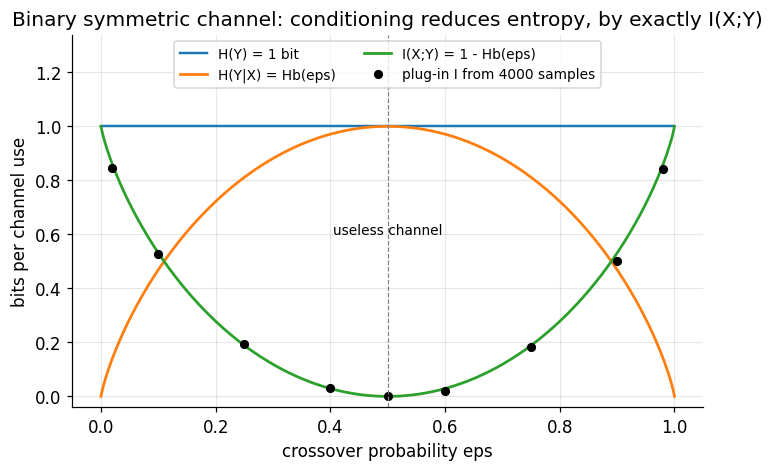

H(Y|X) never exceeds H(Y): True
I(X;Y) >= 0 everywhere    : True
I at eps = 0, 0.5, 1      : 1.0000, 0.0000, 1.0000
plug-in I at eps = 0.5    : 0.000001 bits (exact value 0)


In [9]:
eps_grid = np.linspace(0.0, 1.0, 401)
Hy_curve = np.ones_like(eps_grid)
Hyx_curve = np.array([Hb(e) for e in eps_grid])
I_curve = Hy_curve - Hyx_curve

eps_pts = np.array([0.02, 0.1, 0.25, 0.4, 0.5, 0.6, 0.75, 0.9, 0.98])
Nmc = 4000
I_hat = []
for e in eps_pts:
    x = rng.integers(0, 2, size=Nmc)
    y = x ^ (rng.random(Nmc) < e).astype(int)
    tab = np.zeros((2, 2))
    for i in (0, 1):
        for j in (0, 1):
            tab[i, j] = np.count_nonzero((x == i) & (y == j))
    tab /= Nmc
    I_hat.append(H(tab.sum(axis=1)) + H(tab.sum(axis=0)) - H(tab))

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.plot(eps_grid, Hy_curve, lw=1.6, label="H(Y) = 1 bit")
ax.plot(eps_grid, Hyx_curve, lw=1.8, label="H(Y|X) = Hb(eps)")
ax.plot(eps_grid, I_curve, lw=1.8, label="I(X;Y) = 1 - Hb(eps)")
ax.plot(eps_pts, I_hat, "ko", ms=5, label=f"plug-in I from {Nmc} samples")
ax.axvline(0.5, lw=0.8, ls="--", color="0.5")
ax.annotate("useless channel", (0.5, 0.60), ha="center", fontsize=9)
ax.set_ylim(-0.04, 1.34)
ax.set_xlabel("crossover probability eps")
ax.set_ylabel("bits per channel use")
ax.set_title("Binary symmetric channel: conditioning reduces entropy, by exactly I(X;Y)")
ax.legend(fontsize=9, loc="upper center", ncol=2)
plt.show()

print(f"H(Y|X) never exceeds H(Y): {bool((Hyx_curve <= Hy_curve + 1e-12).all())}")
print(f"I(X;Y) >= 0 everywhere    : {bool((I_curve >= -1e-12).all())}")
print(f"I at eps = 0, 0.5, 1      : {I_curve[0]:.4f}, {I_curve[200]:.4f}, {I_curve[-1]:.4f}")
print(f"plug-in I at eps = 0.5    : {I_hat[4]:.6f} bits (exact value 0)")

The middle curve is $H(Y \mid X)$ and it never rises above the flat line $H(Y) = 1$: that is
Theorem 4.4 drawn. The vertical distance between them is the overlap $I(X;Y)$, which touches $1$
bit at $\varepsilon \in \{0, 1\}$ and vanishes only at $\varepsilon = \tfrac12$, where output and
input are independent.

Two things are worth noticing. A channel that flips *every* bit is as good as one that flips
none — information, unlike accuracy, does not care about relabelling.

And at $\varepsilon = \tfrac12$, where input and output are exactly independent, the plug-in
estimate is still strictly positive. It has to be: the estimator is a mutual information of the
*empirical* table, and Theorem 4.4 forces that to be non-negative whatever the truth is. An
estimated dependence therefore cannot be compared against zero, which is why dependence tests use
a permutation null rather than a threshold on the estimate itself.

### 7.6 The Fano feasible region

Theorem 4.8 says every pair $(P_e, H(Y \mid X))$ arising from an estimator $\hat{Y} = g(X)$ must
lie **below** the curve $H_b(P_e) + P_e \log(K-1)$.

The next figure draws that curve for $K = 10$ together with the weaker linear bound
$1 + P_e \log(K-1)$, and overlays exact $(P_e, H(Y \mid X))$ pairs from two families of channels:
one whose errors are spread uniformly over the nine wrong labels, and one whose errors are
concentrated on a few of them.

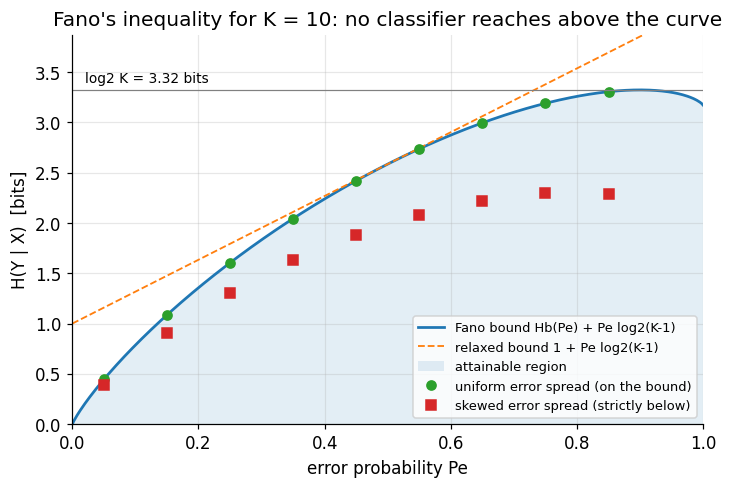

uniform-error family: max (H(Y|X) - Fano bound) = 4.441e-16  -> on the bound
skewed-error family : min slack                 = 0.059518 bits
at H(Y|X) = 2.0 bits the Fano floor on Pe is 0.3409


In [10]:
K = 10
Pe_grid = np.linspace(0.0, 1.0 - 1e-9, 400)
fano_curve = np.array([Hb(t) for t in Pe_grid]) + Pe_grid * np.log2(K - 1)
relaxed = 1.0 + Pe_grid * np.log2(K - 1)

deltas = np.linspace(0.05, 0.85, 9)
pts_uniform, pts_skewed = [], []
for d in deltas:
    # posterior on the true label is 1 - d; the rest is spread over the K-1 wrong ones
    flat = np.concatenate([[1.0 - d], np.full(K - 1, d / (K - 1))])
    w = 0.5 ** np.arange(K - 1)
    skew = np.concatenate([[1.0 - d], d * w / w.sum()])
    pts_uniform.append((d, H(flat)))
    pts_skewed.append((d, H(skew)))
pts_uniform, pts_skewed = np.array(pts_uniform), np.array(pts_skewed)

fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.plot(Pe_grid, fano_curve, lw=1.8, label="Fano bound Hb(Pe) + Pe log2(K-1)")
ax.plot(Pe_grid, relaxed, lw=1.2, ls="--", label="relaxed bound 1 + Pe log2(K-1)")
ax.fill_between(Pe_grid, 0.0, fano_curve, alpha=0.12, label="attainable region")
ax.plot(pts_uniform[:, 0], pts_uniform[:, 1], "o", ms=6, label="uniform error spread (on the bound)")
ax.plot(pts_skewed[:, 0], pts_skewed[:, 1], "s", ms=6, label="skewed error spread (strictly below)")
ax.axhline(np.log2(K), lw=0.8, color="0.5")
ax.annotate("log2 K = 3.32 bits", (0.02, np.log2(K) + 0.07), fontsize=9)
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, np.log2(K) + 0.55)
ax.set_xlabel("error probability Pe")
ax.set_ylabel("H(Y | X)  [bits]")
ax.set_title(f"Fano's inequality for K = {K}: no classifier reaches above the curve")
ax.legend(fontsize=8.5, loc="lower right")
plt.show()

viol_u = np.max(pts_uniform[:, 1] - (np.array([Hb(t) for t in pts_uniform[:, 0]])
                                     + pts_uniform[:, 0] * np.log2(K - 1)))
gap_s = np.min(np.array([Hb(t) for t in pts_skewed[:, 0]]) + pts_skewed[:, 0] * np.log2(K - 1)
               - pts_skewed[:, 1])
print(f"uniform-error family: max (H(Y|X) - Fano bound) = {viol_u:.3e}  -> on the bound")
print(f"skewed-error family : min slack                 = {gap_s:.6f} bits")
floor_idx = int(np.argmax(fano_curve >= 2.0))
print(f"at H(Y|X) = 2.0 bits the Fano floor on Pe is {Pe_grid[floor_idx]:.4f}")
assert viol_u < 1e-12
assert gap_s > 0.0

The circles lie exactly on the curve. That is the equality case of Proof 5.8: when the posterior
mass on the error event is spread uniformly over the $K-1$ wrong labels, Fano is not an
inequality at all.

The squares, whose error mass is concentrated on a few labels, sit strictly below with at least
$0.0595$ bits of slack and up to about a bit at the noisier end — a concentrated error is *more*
informative than a diffuse one of the same probability, so it leaves less residual entropy.

The dashed line is the relaxed form. It is a genuine upper bound but a visibly worse one, and
reading a floor on $P_e$ off the dashed line instead of the curve understates the floor.

## 8. Applications

Four settings in which the chain rule is not an analogy but the actual computation being
performed.

### 8.1 Autoregressive language models are the chain rule

A model that factors a sequence as $q(x_1, \dots, x_n) = \prod_t q(x_t \mid x_{\lt t})$ and is
trained with the token-level log loss is computing one term of Theorem 4.2 at a time.

If the model's conditionals were exactly the true ones, its expected loss at position $t$ would be

$$
\mathbb{E}\bigl[-\log p(X_t \mid X_{\lt t})\bigr] = H\bigl(X_t \mid X_{\lt t}\bigr),
$$

and its expected total loss would be $\sum_t H(X_t \mid X_{\lt t}) = H(X_1, \dots, X_n)$ exactly.

For a stationary source, Theorem 4.10 says that per-token quantity converges to the entropy rate
$H_\infty$. So the loss curve of a language model has a floor, that floor is a property of the
language and not of the architecture, and everything above it is model error.

Two consequences follow from Theorem 4.4(b) alone. Longer context can never increase the *true*
conditional entropy, so more context never hurts; and because Section 7.2 showed the plug-in
estimator is biased downwards by an amount growing with the number of cells, an *estimated*
conditional entropy from a short sample can violate that monotonicity and routinely does.

### 8.2 Feature selection and decision trees

Information gain is the subadditivity gap of Theorem 4.5 in disguise:

$$
\operatorname{IG}(Y; X) = H(Y) - H(Y \mid X) = I(X; Y) \ \ge \ 0 ,
$$

non-negative by Theorem 4.4, so no split can *increase* label entropy on the training set.

That non-negativity is also the pathology. A feature with one distinct value per example drives
$H(Y \mid X)$ to zero and scores a perfect gain while generalizing not at all, so C4.5 divides by
the split entropy,

$$
\operatorname{GR}(Y; X) = \frac{H(Y) - H(Y \mid X)}{H(X)},
$$

penalizing features whose gain comes from having many values. Section 7.2 gives the second half of
the story: on finite samples the plug-in gain is biased *upwards*, and the bias grows with the
number of cells in the joint table, so high-cardinality features are doubly favoured.

Theorem 4.7 supplies the stopping rule: a leaf with $H(Y \mid \text{leaf}) = 0$ is pure and cannot
be improved.

### 8.3 Physics: Landauer's principle and Maxwell's demon

Maxwell's demon observes the microstate $X$ of a gas, records the result as $M$, and uses $M$ to
extract work — apparently violating the second law. The resolution is an entropy budget, and this
module supplies the piece that closes it.

Two thermodynamic facts are used, both cited rather than proved here.

**(i) Feedback bound.** In an isothermal cycle at temperature $T$, the work extractable using a
measurement record $M$ of the system state $X$ obeys

$$
W_{\text{ext}} \le k_B T \, I(X; M) \qquad \text{(nats)} .
$$

**(ii) Landauer's principle.** Resetting the record to a standard state costs at least

$$
W_{\text{erase}} \ge k_B T \, H(M) \qquad \text{(nats)} .
$$

Now the information theory. By Theorem 4.1 and the non-negativity of conditional entropy in
Proposition 4.6,

$$
I(X; M) = H(M) - H(M \mid X) \le H(M) .
$$

Subtracting,

$$
W_{\text{net}} = W_{\text{ext}} - W_{\text{erase}} \le k_B T \bigl( I(X;M) - H(M) \bigr) = -\,k_B T \, H(M \mid X) \ \le \ 0 .
$$

$$
\boxed{W_{\text{net}} \le -\,k_B T \, H(M \mid X)}
$$

**Interpretation.** Meaning: the demon's deficit per cycle is exactly the *noise in its own
measurement*, measured as conditional entropy. Consequence: break-even requires
$H(M \mid X) = 0$, which by Theorem 4.7 means the record is a deterministic function of the
system state — a noiseless measurement. Any measurement error is a strictly positive tax, and the
second law is safe.

Sources: Landauer (1961) for (ii); Sagawa and Ueda, *Phys. Rev. Lett.* **100**, 080403 (2008) for
(i); Bérut et al., *Nature* **483** (2012), 187-189 for the experimental confirmation of the
$k_B T \ln 2$ per erased bit.

### 8.4 Distributed compression: the Slepian-Wolf region (cited, not proved here)

Theorem 4.5 says correlated sources compress better together: $H(X, Y) \le H(X) + H(Y)$. The
obvious reading is that the two encoders must talk to each other.

They need not. If $X$ and $Y$ are encoded **separately** at rates $R_X$ and $R_Y$ and decoded
jointly, arbitrarily reliable reconstruction of a long i.i.d. sequence of pairs is possible for
every rate pair in

$$
R_X \ge H(X \mid Y), \qquad R_Y \ge H(Y \mid X), \qquad R_X + R_Y \ge H(X, Y),
$$

and impossible outside it. The total $H(X,Y)$ is achievable with no communication between the
encoders at all.

This is the **Slepian-Wolf theorem**; its proof needs random binning and the asymptotic
equipartition property, neither of which this module develops. Statement and proof:
Cover & Thomas, *Elements of Information Theory*, 2nd ed., section 15.4 (Theorem 15.4.1);
original paper Slepian and Wolf, *IEEE Trans. Inform. Theory* **19**(4) (1973), 471-480.

For the running example of Section 6.1 the region has corner points
$(R_X, R_Y) = (0.811, 0.689)$ and $(0.5, 1.0)$, both summing to $H(X,Y) = 1.5$ bits against the
$1.811$ bits that independent encoding *and* independent decoding would need.

The cell below runs the three quantitative applications: the per-token loss of a model on a
stationary Markov source against the entropy rate of Theorem 4.10, the information gain and gain
ratio of a three-way split, and the Landauer energy budget at room temperature.

In [11]:
# --- 8.1 per-token loss of a Markov source ------------------------------------
a, b = 0.2, 0.4
Pm = np.array([[1 - a, a], [b, 1 - b]])
pi = np.array([b, a]) / (a + b)
H_rate = float(pi @ np.array([Hb(a), Hb(b)]))

n = 200_000
seq = np.empty(n, dtype=int)
seq[0] = int(rng.random() > pi[0])
u = rng.random(n)
for t in range(1, n):
    seq[t] = int(u[t] > Pm[seq[t - 1], 0])
loss = float(np.mean([-np.log2(Pm[seq[t - 1], seq[t]]) for t in range(1, n)]))
print("8.1 autoregressive loss on a stationary Markov source")
print(f"    stationary pi                    = {pi}")
print(f"    empirical state frequencies      = {np.bincount(seq) / n}")
print(f"    entropy rate H_inf (Theorem 4.10)= {H_rate:.6f} bits/step")
print(f"    measured teacher-forcing loss    = {loss:.6f} bits/step")
print(f"    marginal-only coder H(pi)        = {H(pi):.6f} bits/step")
print(f"    one step of memory is worth      = {H(pi) - H_rate:.6f} bits/step")
assert abs(loss - H_rate) < 5e-3
assert H_rate < H(pi)

# --- 8.2 information gain of a three-way split --------------------------------
children = np.array([[4.0, 0.0], [0.0, 4.0], [2.0, 2.0]])
total = children.sum()
w = children.sum(axis=1) / total
Hy_parent = H(children.sum(axis=0) / total)
Hy_given = float(sum(w[i] * H(children[i] / children[i].sum()) for i in range(3)))
Hx_split = H(w)
print("\n8.2 decision-tree split: 12 examples, groups of 4/4/4")
print(f"    H(Y) parent      = {Hy_parent:.6f} bits")
print(f"    H(Y | split)     = {Hy_given:.6f} bits")
print(f"    information gain = {Hy_parent - Hy_given:.6f} bits")
print(f"    split entropy    = {Hx_split:.6f} bits    gain ratio = "
      f"{(Hy_parent - Hy_given) / Hx_split:.6f}")
assert abs(Hy_parent - 1.0) < 1e-12
assert abs(Hy_given - 1 / 3) < 1e-12
assert Hy_parent - Hy_given >= -1e-12

# --- 8.3 Landauer budget -------------------------------------------------------
kB, T = 1.380649e-23, 300.0
per_bit = kB * T * np.log(2.0)
print("\n8.3 Landauer budget at T = 300 K")
print(f"    kB T ln 2                    = {per_bit:.4e} J per erased bit")
print(f"    erasing 1 GiB                = {per_bit * 8 * 2**30:.4e} J")
for eps_meas in (0.0, 0.05, 0.2):
    H_M_given_X = Hb(eps_meas)
    print(f"    demon with measurement error {eps_meas:>4}: deficit >= "
          f"{kB * T * np.log(2.0) * H_M_given_X:.4e} J per cycle "
          f"(H(M|X) = {H_M_given_X:.4f} bits)")
assert per_bit > 0.0
assert Hb(0.2) > Hb(0.05) > Hb(0.0)

8.1 autoregressive loss on a stationary Markov source
    stationary pi                    = [0.6667 0.3333]
    empirical state frequencies      = [0.6677 0.3323]
    entropy rate H_inf (Theorem 4.10)= 0.804936 bits/step
    measured teacher-forcing loss    = 0.804033 bits/step
    marginal-only coder H(pi)        = 0.918296 bits/step
    one step of memory is worth      = 0.113360 bits/step

8.2 decision-tree split: 12 examples, groups of 4/4/4
    H(Y) parent      = 1.000000 bits
    H(Y | split)     = 0.333333 bits
    information gain = 0.666667 bits
    split entropy    = 1.584963 bits    gain ratio = 0.420620

8.3 Landauer budget at T = 300 K
    kB T ln 2                    = 2.8710e-21 J per erased bit
    erasing 1 GiB                = 2.4662e-11 J
    demon with measurement error  0.0: deficit >= 0.0000e+00 J per cycle (H(M|X) = 0.0000 bits)
    demon with measurement error 0.05: deficit >= 8.2224e-22 J per cycle (H(M|X) = 0.2864 bits)
    demon with measurement error  0.2: 

The measured teacher-forcing loss on a $200{,}000$-step trajectory is $0.804033$ bits per step
against the exact entropy rate $0.804936$, a Monte-Carlo discrepancy of $9 \times 10^{-4}$ bits.
The floor of Theorem 4.10 is reached and not merely approached, because the model scoring the
sequence here *is* the true conditional. A coder that knows only the climatology $\pi$ pays
$0.918296$ bits, so one step of memory is worth $0.113360$ bits per day.

The three-way split takes label entropy from $1$ bit to $\tfrac13$ bit, an information gain of
$\tfrac23$ bit; dividing by the split entropy $\log_2 3 = 1.585$ gives the gain ratio $0.421$.

Landauer's constant at room temperature is $2.8710 \times 10^{-21}$ joules per bit, so erasing
one gibibyte costs $2.4662 \times 10^{-11}$ joules — far below what any physical memory
technology actually spends, which is why the bound constrains physics rather than engineering.

A demon whose measurement has a $20\%$ error rate runs a deficit of at least
$2.0726 \times 10^{-21}$ joules every cycle, because $H(M \mid X) = H_b(0.2) = 0.7219$ bits of its
record is pure noise that still has to be erased. Only the noiseless demon, $H(M \mid X) = 0$,
breaks even.

## 9. Key Takeaways

- **The chain rule is an exact identity, not a bound**: $H(X,Y) = H(X) + H(Y \mid X) = H(Y) + H(X \mid Y)$
  for every joint distribution on finite alphabets (Theorem 4.1). Section 7.1 measures its
  residual as exactly zero across ten random tables, sparse ones included.

- **Any ordering, same total**: $H(X_1,\dots,X_n) = \sum_i H(X_i \mid X_{\lt i})$ (Theorem 4.2).
  Example 6.2 splits $1.811278$ bits as $1 + 0.811 + 0$ and as $0.811 + 1 + 0$.

- **Conditioning reduces entropy on average, and only on average**: $H(Y \mid X) \le H(Y)$ with
  equality exactly at independence (Theorem 4.4). Example 6.3 has a slice at $1$ bit against a
  marginal of $0.286$ bits.

- **The module's central inequality is self-contained**: it comes from
  $D(p \parallel q) \ge 0$ (Lemma 4.3), which comes from $\ln t \le t-1$ in three lines
  (Proof 5.3). Nothing here is imported from a later module.

- **Dependence compresses, and the equality case is mutual**: $H(X_1,\dots,X_n) \le \sum_i H(X_i)$
  with equality iff mutually independent (Theorem 4.5). The pairwise independent XOR triple of
  Example 6.5 misses equality by a full bit.

- **Zero residual uncertainty means computability**: $H(Y \mid X) = 0$ iff $Y = f(X)$ almost
  surely (Theorem 4.7) — $f$ may be many-to-one.

- **Fano converts entropy into an error floor, and it is attained**:
  $H(Y \mid X) \le H_b(P_e) + P_e\log(K-1)$ for any $\hat{Y} = g(X)$ (Theorem 4.8). Example 6.4
  meets it with equality; Section 7.3 shows it fails the moment the estimator is allowed to see
  $Y$.

- **Han's inequality bounds a whole by its $(n-1)$-subsets** (Theorem 4.9), and is tight for
  independent variables — the entropy form of a projection-counting argument.

- **Stationary sources have a bits-per-symbol constant**: $a_n$ is non-increasing and
  $\frac1n H(X_{1:n}) \to H_\infty$ (Theorem 4.10). Drop stationarity and Section 7.3 exhibits
  $a_1 = 1 \lt a_2 = 2$.

- **Estimated entropies are biased downwards by $(S-1)/(2N\ln 2)$ bits**, measured in Section 7.2
  at observed orders $1.0029$ and $0.9951$ in $1/N$ against the predicted $1$. Joint tables have
  more cells than marginals, so empirical information gains are inflated.

## 10. References

**Textbooks.**

- Cover, T. M. and Thomas, J. A. *Elements of Information Theory*, 2nd ed. — joint and conditional
  entropy and the chain rules (section 2.2, section 2.5, Theorem 2.5.1); conditioning reduces
  entropy and the independence bound (section 2.6, Theorem 2.6.5); Fano's inequality
  (section 2.10, Theorem 2.10.1); entropy rate of a stationary process and of a Markov chain
  (section 4.2, Theorems 4.2.1 and 4.2.4); Han's inequality (section 17.6); Slepian-Wolf
  (section 15.4, Theorem 15.4.1).
- MacKay, D. J. C. *Information Theory, Inference, and Learning Algorithms*, chapter 8 (dependent
  random variables, the two-variable information diagram) and chapter 9 (the binary symmetric
  channel).
- Yeung, R. W. *Information Theory and Network Coding*, chapter 3 — the I-Measure, and the precise
  sense in which two-variable entropy diagrams are signed measures while three-variable ones are
  not.
- Polyanskiy, Y. and Wu, Y. *Information Theory: From Coding to Learning*, chapters 1 to 3 —
  entropy, divergence and the modern treatment of Fano.
- Shannon, C. E. "A Mathematical Theory of Communication", *Bell System Technical Journal* **27**
  (1948), sections 11 and 12 — the original joint and conditional entropies and the entropy rate
  of a source.

**Papers.**

- Fano, R. M. *Transmission of Information*, MIT Press (1961) — the original inequality.
- Slepian, D. and Wolf, J. K. "Noiseless coding of correlated information sources",
  *IEEE Transactions on Information Theory* **19**(4) (1973), 471-480.
- Landauer, R. "Irreversibility and heat generation in the computing process",
  *IBM Journal of Research and Development* **5**(3) (1961), 183-191.
- Sagawa, T. and Ueda, M. "Second law of thermodynamics with discrete quantum feedback control",
  *Physical Review Letters* **100** (2008), 080403.
- Bérut, A. et al. "Experimental verification of Landauer's principle linking information and
  thermodynamics", *Nature* **483** (2012), 187-189.
- Miller, G. A. "Note on the bias of information estimates", in *Information Theory in Psychology*
  (1955), 95-100 — the $(S-1)/2N$ bias measured in Section 7.2.

**Within this repository.**

- Prerequisites and downstream modules: [the module graph](../../docs/prerequisites.md).
- Symbol conventions, including the joint-versus-cross-entropy ruling:
  [the notation register](../../docs/notation.md).
- Entropy of a single variable, the maximum-entropy bound and differential entropy:
  [Module 01](../01_self_information_and_entropy/).
- Relative entropy in its own right, $f$-divergences and Pinsker:
  [Module 04](../04_kl_divergence_and_f_divergences/).
- Mutual information, conditional mutual information and the data-processing inequality:
  [Module 05](../05_mutual_information/).
- Practice problems for this module: [exercises.ipynb](exercises.ipynb).